# UNKNOWN-FIRST — Novelty-Aware Malware Triage System

**Code Cortex 3.0 · Team Garnet_Chronicles · Machine-learning component**

This notebook builds three things:

1. **A static Windows PE malware classifier** (XGBoost). It gives each sample a *malware probability*.
2. **A novelty detector** (Isolation Forest). It gives each sample a *novelty score*: how unusual the sample looks compared with the training data.
3. **A triage engine** that combines both scores and returns exactly one of three verdicts:

| Verdict | Meaning |
|---|---|
| `MALWARE` | The classifier is confident it is malware **and** the sample looks familiar. |
| `BENIGN` | The classifier is confident it is benign **and** the sample looks familiar. |
| `NEEDS_ANALYSIS` | The sample is ambiguous and/or structurally novel compared with the training distribution, so deeper analysis is recommended. |

> **What this system does:** This system combines malware classification with novelty detection and abstention. A sample that is ambiguous or structurally unfamiliar is sent to NEEDS_ANALYSIS instead of forcing a binary decision.

**What this system is NOT:** it is not a zero-day detector, not an AI-generated-malware detector, not a polymorphic-malware detector and not a fileless-malware detector. The dataset only has static features that were already extracted from PE files. The model can only learn from those features.

**How to run it**

1. Upload `malware.csv` to Google Drive at `MyDrive/UNKNOWN_FIRST/malware.csv` (or change `DRIVE_PROJECT_DIR` in the settings cell).
2. Click **Runtime → Run all** and allow Google Drive access when Colab asks.

Everything the notebook produces (figures, reports and the `ml_package/` inference package) is saved next to the dataset on Google Drive.

## Section 0 — Setup

In this section we:

* install the libraries,
* import everything in **one** cell,
* put every setting (paths, seeds, model settings, thresholds) in **one** settings cell,
* connect Google Drive and create the project folders,
* define a few small helper functions that the whole notebook uses.

In [ ]:
# We install the libraries this notebook needs. Colab already has most of them.
# We do not force upgrades, so Colab does not need a restart after this cell.
%pip install -q xgboost shap scikit-learn pandas numpy matplotlib seaborn joblib

In [ ]:
# Every library import lives in this one cell, so it is easy to see what the notebook depends on.
import importlib
import importlib.util
import itertools
import json
import math
import platform
import shutil
import subprocess
import sys
import textwrap
import time
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import sklearn
import xgboost as xgb
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, QuantileTransformer
from xgboost import XGBClassifier

# Google Drive only exists inside Colab, so we check where we are before importing it.
# (We check "google" first, because asking for "google.colab" crashes when "google" is not installed.)
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    from google.colab import drive

# We record library versions because saved models only load reliably with the same versions.
LIBRARY_VERSIONS = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "xgboost": xgb.__version__,
    "shap": shap.__version__,
    "joblib": joblib.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__,
}
for library_name, library_version in LIBRARY_VERSIONS.items():
    print(f"{library_name:<13} {library_version}")
print("\nRunning on Google Colab:", IN_COLAB)

python        3.13.15
numpy         2.1.3
pandas        2.2.3
scikit-learn  1.6.1
xgboost       3.4.1
shap          0.52.0
joblib        1.6.0
matplotlib    3.10.0
seaborn       0.13.2

Running on Google Colab: True


In [ ]:
# ---------------------------------------------------------------------------
# SETTINGS — everything you might want to change lives in this one cell.
# ---------------------------------------------------------------------------

# One seed for everything, so every run gives the same splits and the same models.
RANDOM_STATE = 42

# ---- Paths -----------------------------------------------------------------
# On Colab we save to Google Drive, so the files survive after the runtime shuts down.
USE_GOOGLE_DRIVE = True
DRIVE_MOUNT_POINT = "/content/drive"
DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/UNKNOWN_FIRST")  # put malware.csv in this folder
LOCAL_PROJECT_DIR = Path.cwd() / "UNKNOWN_FIRST"                  # only used when not on Colab

PROJECT_DIR = DRIVE_PROJECT_DIR if (IN_COLAB and USE_GOOGLE_DRIVE) else LOCAL_PROJECT_DIR
DATA_PATH = Path("/content/malware.csv")
FIGURES_DIR = PROJECT_DIR / "figures"
REPORTS_DIR = PROJECT_DIR / "reports"
PACKAGE_DIR = PROJECT_DIR / "ml_package"   # the inference package for the API team
ARTIFACTS_DIR = PACKAGE_DIR / "artifacts"
TRIAGE_RULES_PATH = PACKAGE_DIR / "triage_rules.py"
PREDICTOR_PATH = PACKAGE_DIR / "predictor.py"
PACKAGE_INIT_PATH = PACKAGE_DIR / "__init__.py"
PACKAGE_README_PATH = PACKAGE_DIR / "README.md"
PACKAGE_REQUIREMENTS_PATH = PACKAGE_DIR / "requirements.txt"
EXAMPLE_REQUEST_PATH = PACKAGE_DIR / "example_request.json"

# The exact file names of every saved artifact. The API package expects these names.
ARTIFACT_FILE_NAMES = {
    "classifier": "xgb_malware_model.joblib",
    "novelty_detector": "iforest_novelty_model.joblib",
    "preprocessor": "preprocessor.joblib",
    "novelty_transformer": "novelty_score_transformer.joblib",
    "thresholds": "thresholds.json",
    "feature_schema": "feature_schema.json",
    "shap_feature_names": "shap_feature_names.json",
    "model_metadata": "model_metadata.json",
}

# ---- Dataset columns ----------------------------------------------------------
TARGET_COLUMN = "legitimate"          # in the raw file: 1 = benign, 0 = malware
IDENTIFIER_COLUMNS = ["Name", "md5"]  # these name a file; they say nothing about how it is built
# Text columns where more than this share of rows are unique behave like IDs, so we drop them too.
ID_LIKE_UNIQUE_RATIO = 0.5
# Remove rows that are exact copies (same features AND same label) before splitting.
# If one copy lands in train and another in test, the test score looks better than it really is.
DROP_DUPLICATE_ROWS = True

# ---- Data split ---------------------------------------------------------------
TEST_SIZE = 0.20                   # 20% of all rows = the final, untouched test set
VALIDATION_SIZE_WITHIN_DEV = 0.20  # 20% of the other 80% = validation (about 16% of all rows)

# ---- Models ---------------------------------------------------------------------
XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 6,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": RANDOM_STATE,
    "tree_method": "hist",
    "n_jobs": -1,
    "eval_metric": "logloss",
}
IFOREST_PARAMS = {
    "n_estimators": 200,
    "contamination": 0.05,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

# ---- Triage thresholds ------------------------------------------------------------
# These are only STARTING values. Section 6 tests a small grid around them on the validation set.
STARTING_THRESHOLDS = {
    "malware_threshold": 0.85,
    "benign_threshold": 0.15,
    "novelty_threshold": 0.95,
}
MALWARE_THRESHOLD_GRID = [0.75, 0.80, 0.85, 0.90, 0.95]
BENIGN_THRESHOLD_GRID = [0.05, 0.10, 0.15, 0.20, 0.25]
NOVELTY_THRESHOLD_GRID = [0.90, 0.93, 0.95, 0.97, 0.99]
# The analyst budget: at most this share of samples may be sent to NEEDS_ANALYSIS.
MAX_ABSTENTION_RATE = 0.10

# ---- Confidence rule (a transparent rule, NOT a calibrated probability) -------------
# HIGH needs the probability to be at least this fraction of the way from its threshold to 0 or 1 ...
HIGH_CONFIDENCE_MARGIN = 0.5
# ... and the sample must be more familiar than this novelty score.
HIGH_CONFIDENCE_MAX_NOVELTY = 0.80

# ---- Synthetic novelty stress test --------------------------------------------------
STRESS_TEST_SAMPLE_SIZE = 2000
STRESS_TEST_SHIFTS_IN_STD = [0, 1, 2, 3, 5]  # 0 = unchanged copy (the control group)

# ---- SHAP ----------------------------------------------------------------------------
SHAP_SAMPLE_SIZE = 3000
TOP_N_FEATURES = 15
TOP_SHAP_FEATURES_PER_SAMPLE = 5

# ---- Package metadata ---------------------------------------------------------------
MODEL_VERSION = "1.0.0"

print("Project folder:", PROJECT_DIR)
print("Dataset path:  ", DATA_PATH)

Project folder: /content/drive/MyDrive/UNKNOWN_FIRST
Dataset path:   /content/malware.csv


In [ ]:
# We connect Google Drive first, because every output is saved there.
# Folders are created only AFTER mounting; creating them before would block the mount.
if IN_COLAB and USE_GOOGLE_DRIVE:
    drive.mount(DRIVE_MOUNT_POINT)
else:
    print("Google Drive is not used (not on Colab, or USE_GOOGLE_DRIVE = False).")
    print("Using this local folder instead:", PROJECT_DIR)

for folder in [PROJECT_DIR, FIGURES_DIR, REPORTS_DIR, PACKAGE_DIR, ARTIFACTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# We add the project folder to Python's search path so we can import our own ml_package later.
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("Folders ready:")
for folder in [PROJECT_DIR, FIGURES_DIR, REPORTS_DIR, PACKAGE_DIR, ARTIFACTS_DIR]:
    print("  ", folder)

Mounted at /content/drive
Folders ready:
   /content/drive/MyDrive/UNKNOWN_FIRST
   /content/drive/MyDrive/UNKNOWN_FIRST/figures
   /content/drive/MyDrive/UNKNOWN_FIRST/reports
   /content/drive/MyDrive/UNKNOWN_FIRST/ml_package
   /content/drive/MyDrive/UNKNOWN_FIRST/ml_package/artifacts


In [ ]:
# One plotting style for the whole notebook, so all charts look consistent.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

LABEL_NAMES = {0: "benign", 1: "malware"}
CLASS_COLORS = {"benign": "#2a9d8f", "malware": "#d62828"}
VERDICT_ORDER = ["MALWARE", "BENIGN", "NEEDS_ANALYSIS"]
VERDICT_COLORS = {"MALWARE": "#d62828", "BENIGN": "#2a9d8f", "NEEDS_ANALYSIS": "#e9a23b"}

# The one honest sentence that describes this system. We reuse it in reports and metadata.
SYSTEM_STATEMENT = (
    "This system combines malware classification with novelty detection and abstention. "
    "A sample that is ambiguous or structurally unfamiliar is sent to NEEDS_ANALYSIS "
    "instead of forcing a binary decision."
)


def save_and_show(fig, file_name, tight=True):
    """Save a figure into the figures folder (handy for the pitch deck), then show it."""
    if tight:
        fig.tight_layout()
    fig.savefig(FIGURES_DIR / file_name, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def to_json_safe(value):
    """Turn numpy/pandas values into plain Python values, because JSON cannot store numpy types."""
    if isinstance(value, dict):
        return {str(key): to_json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_json_safe(item) for item in value]
    if isinstance(value, np.bool_):
        return bool(value)
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        value = float(value)
    if isinstance(value, float) and not math.isfinite(value):
        return None  # JSON has no NaN or infinity, so we store null instead
    if isinstance(value, Path):
        return str(value)
    return value


def save_json(data, path):
    """Save data as a readable JSON file."""
    with open(path, "w", encoding="utf-8") as handle:
        json.dump(to_json_safe(data), handle, indent=2)
    print(f"Saved {path}")


def load_json(path):
    """Read a JSON file back into Python."""
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)


def as_percent(value, decimals=2):
    """0.1234 -> '12.34%'. Makes printed results easier to read."""
    if value is None or (isinstance(value, (float, np.floating)) and math.isnan(value)):
        return "n/a"
    return f"{100 * value:.{decimals}f}%"

## Section 1 — Load and inspect the data

We look at the **real file** before we trust any column name.

* Some copies of this dataset use `|` instead of `,` between columns, so we detect the separator automatically.
* If the file or the label column `legitimate` is missing, the notebook stops with a clear message.

In [ ]:
def detect_separator(csv_path, candidates=(",", "|", ";", "\t")):
    """Guess the column separator by counting each candidate in the header line."""
    with open(csv_path, "r", encoding="utf-8-sig", errors="replace") as handle:
        header_line = handle.readline()
    counts = {separator: header_line.count(separator) for separator in candidates}
    best_separator = max(counts, key=counts.get)
    if counts[best_separator] == 0:
        raise ValueError(
            f"Could not find a column separator in the first line of {csv_path}.\n"
            f"First line was: {header_line[:200]!r}"
        )
    return best_separator


def load_dataset(csv_path):
    """Load the CSV and stop with a clear message if it is missing or broken."""
    if not csv_path.is_file():
        folder = csv_path.parent
        csv_files = sorted(path.name for path in folder.glob("*.csv")) if folder.is_dir() else []
        raise FileNotFoundError(
            f"Dataset not found at: {csv_path}\n"
            f"CSV files in {folder}: {csv_files if csv_files else 'none'}\n"
            "Upload malware.csv to that folder, or change DRIVE_PROJECT_DIR / DATA_PATH in the settings cell."
        )
    separator = detect_separator(csv_path)
    df = pd.read_csv(csv_path, sep=separator, encoding="utf-8-sig", encoding_errors="replace", low_memory=False)

    # Extra spaces in column names would break exact name matching later, so we strip them.
    original_columns = list(df.columns)
    df.columns = [str(column).strip() for column in df.columns]
    renamed = [(old, new) for old, new in zip(original_columns, df.columns) if old != new]
    if renamed:
        print("Removed extra spaces from these column names:", renamed)

    if df.columns.duplicated().any():
        raise ValueError(f"Duplicate column names found: {df.columns[df.columns.duplicated()].tolist()}")
    if df.empty or df.shape[1] < 2:
        raise ValueError(
            f"The file loaded with shape {df.shape}. Check the separator ({separator!r}) and the file content."
        )
    return df, separator


raw_df, detected_separator = load_dataset(DATA_PATH)
print(f"Loaded {DATA_PATH.name} using separator {detected_separator!r}")
print(f"Shape: {raw_df.shape}")
print(f"Number of rows:    {raw_df.shape[0]:,}")
print(f"Number of columns: {raw_df.shape[1]:,}")

Loaded malware.csv using separator '|'
Shape: (138047, 57)
Number of rows:    138,047
Number of columns: 57


In [ ]:
# A first look at real rows, so we never have to guess what the data looks like.
display(raw_df.head())

print("All column names:")
print(list(raw_df.columns))

# The data type tells us which columns are numbers and which are text.
column_overview = pd.DataFrame(
    {
        "dtype": raw_df.dtypes.astype(str),
        "non_null_values": raw_df.notna().sum(),
        "unique_values": raw_df.nunique(dropna=True),
    }
)
display(column_overview)
print("How many columns of each dtype:")
print(raw_df.dtypes.astype(str).value_counts().to_string())

,Name,md5,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,...,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate
0,memtest.exe,631ea355665f28d4707448e442fbf5b8,332,224,258,9,0,361984,115712,0,...,4,3.262823,2.568844,3.537939,8797.000000,216,18032,0,16,1
1,ose.exe,9d10f99a6712e28f8acd5641e3a7ea6b,332,224,3330,9,0,130560,19968,0,...,2,4.250461,3.420744,5.080177,837.000000,518,1156,72,18,1
2,setup.exe,4d92f518527353c0db88a70fddcfd390,332,224,3330,9,0,517120,621568,0,...,11,4.426324,2.846449,5.271813,31102.272727,104,270376,72,18,1
3,DW20.EXE,a41e524f8d45f0074fd07805ff0c9b12,332,224,258,9,0,585728,369152,0,...,10,4.364291,2.669314,6.400720,1457.000000,90,4264,72,18,1
4,dwtrig20.exe,c87e561258f2f8650cef999bf643a731,332,224,258,9,0,294912,247296,0,...,2,4.306100,3.421598,5.190603,1074.500000,849,1300,72,18,1


All column names:
['Name', 'md5', 'Machine', 'SizeOfOptionalHeader', 'Characteristics', 'MajorLinkerVersion', 'MinorLinkerVersion', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'SectionAlignment', 'FileAlignment', 'MajorOperatingSystemVersion', 'MinorOperatingSystemVersion', 'MajorImageVersion', 'MinorImageVersion', 'MajorSubsystemVersion', 'MinorSubsystemVersion', 'SizeOfImage', 'SizeOfHeaders', 'CheckSum', 'Subsystem', 'DllCharacteristics', 'SizeOfStackReserve', 'SizeOfStackCommit', 'SizeOfHeapReserve', 'SizeOfHeapCommit', 'LoaderFlags', 'NumberOfRvaAndSizes', 'SectionsNb', 'SectionsMeanEntropy', 'SectionsMinEntropy', 'SectionsMaxEntropy', 'SectionsMeanRawsize', 'SectionsMinRawsize', 'SectionMaxRawsize', 'SectionsMeanVirtualsize', 'SectionsMinVirtualsize', 'SectionMaxVirtualsize', 'ImportsNbDLL', 'ImportsNb', 'ImportsNbOrdinal', 'ExportNb', 'ResourcesNb', 'ResourcesMeanEntropy', 'ResourcesMinEntropy'

,dtype,non_null_values,unique_values
Name,object,138047,107488
md5,object,138047,138047
Machine,int64,138047,3
SizeOfOptionalHeader,int64,138047,5
Characteristics,int64,138047,104
MajorLinkerVersion,int64,138047,41
MinorLinkerVersion,int64,138047,62
SizeOfCode,int64,138047,3809
SizeOfInitializedData,int64,138047,3217
SizeOfUninitializedData,int64,138047,441


How many columns of each dtype:
int64      45
float64     9
object      2
uint64      1


In [ ]:
# Missing values matter because the models need a value in every cell (we fill gaps in Section 2).
missing_counts = raw_df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
if missing_counts.empty:
    print("Missing values: none in any column.")
else:
    print(f"Missing values found in {len(missing_counts)} columns:")
    missing_table = missing_counts.rename("missing_count").to_frame()
    missing_table["missing_percent"] = (100 * missing_table["missing_count"] / len(raw_df)).round(3)
    display(missing_table)

# Exact duplicate rows can leak between train and test, so we count them now.
print(f"Fully duplicated rows (every column identical, including Name/md5): {raw_df.duplicated().sum():,}")

# Basic statistics show the scale and spread of every column.
print("\nBasic descriptive statistics:")
display(raw_df.describe(include="all").T)

Missing values: none in any column.
Fully duplicated rows (every column identical, including Name/md5): 0

Basic descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,138047,107488,mshtml.dll,187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
md5,138047,138047,d7648eae45f09b3adb75127f43be6d11,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Machine,138047.0,NaN,NaN,NaN,4259.069274,10880.347245,332.0,332.0,332.0,332.0,34404.0
SizeOfOptionalHeader,138047.0,NaN,NaN,NaN,225.845632,5.121399,224.0,224.0,224.0,224.0,352.0
Characteristics,138047.0,NaN,NaN,NaN,4444.145994,8186.782524,2.0,258.0,258.0,8226.0,49551.0
MajorLinkerVersion,138047.0,NaN,NaN,NaN,8.619774,4.088757,0.0,8.0,9.0,10.0,255.0
MinorLinkerVersion,138047.0,NaN,NaN,NaN,3.819286,11.862675,0.0,0.0,0.0,0.0,255.0
SizeOfCode,138047.0,NaN,NaN,NaN,242595.562656,5754485.404037,0.0,30208.0,113664.0,120320.0,1818586738.0
SizeOfInitializedData,138047.0,NaN,NaN,NaN,450486.674763,21015985.183457,0.0,24576.0,263168.0,385024.0,4294966272.0
SizeOfUninitializedData,138047.0,NaN,NaN,NaN,100952.505299,16352876.182061,0.0,0.0,0.0,0.0,4294940713.0


In [ ]:
# PE features that often appear in this dataset. We only REPORT which ones exist;
# the model uses whatever columns are really in the file.
COMMON_PE_FEATURES = [
    "Machine", "SectionsMeanEntropy", "SectionsMinEntropy", "SectionsMaxEntropy",
    "ImportsNb", "ImportsNbDLL", "ResourcesNb", "DebugSize",
]


def validate_target_column(df, target_column):
    """Stop with a clear message if the label column is missing or has unexpected values."""
    if target_column not in df.columns:
        raise KeyError(
            f"Required target column '{target_column}' is missing.\nColumns found: {list(df.columns)}"
        )
    target = df[target_column]
    if target.isna().any():
        raise ValueError(f"'{target_column}' has {int(target.isna().sum())} missing values. Every row needs a label.")
    unique_values = set(pd.unique(target).tolist())
    if not unique_values.issubset({0, 1}):
        raise ValueError(f"'{target_column}' must only contain 0 and 1, but found: {sorted(unique_values, key=str)}")
    if len(unique_values) < 2:
        raise ValueError(f"'{target_column}' has only one class ({unique_values}). We need both malware and benign rows.")


validate_target_column(raw_df, TARGET_COLUMN)

present_pe_features = [column for column in COMMON_PE_FEATURES if column in raw_df.columns]
absent_pe_features = [column for column in COMMON_PE_FEATURES if column not in raw_df.columns]
print("Common PE features found in this file:", present_pe_features)
print("Common PE features NOT in this file (just information, not an error):", absent_pe_features)

# In the raw file, legitimate = 1 means benign. We flip it so that 1 = malware.
# Security metrics like recall are about catching malware, so malware must be the "positive" class (1).
y_malware_all = (1 - raw_df[TARGET_COLUMN]).astype(int).rename("y_malware")

malware_count = int(y_malware_all.sum())
benign_count = int(len(y_malware_all) - malware_count)
print("\nTarget counts in the raw file:")
print(
    raw_df[TARGET_COLUMN]
    .value_counts()
    .rename(index={1: "legitimate = 1 (benign)", 0: "legitimate = 0 (malware)"})
    .to_string()
)
print("\nAfter the conversion y_malware = 1 - legitimate:")
print(f"  y_malware = 1 (malware): {malware_count:,} rows = {as_percent(malware_count / len(y_malware_all))}")
print(f"  y_malware = 0 (benign):  {benign_count:,} rows = {as_percent(benign_count / len(y_malware_all))}")

Common PE features found in this file: ['Machine', 'SectionsMeanEntropy', 'SectionsMinEntropy', 'SectionsMaxEntropy', 'ImportsNb', 'ImportsNbDLL', 'ResourcesNb']
Common PE features NOT in this file (just information, not an error): ['DebugSize']

Target counts in the raw file:
legitimate
legitimate = 0 (malware)    96724
legitimate = 1 (benign)     41323

After the conversion y_malware = 1 - legitimate:
  y_malware = 1 (malware): 96,724 rows = 70.07%
  y_malware = 0 (benign):  41,323 rows = 29.93%


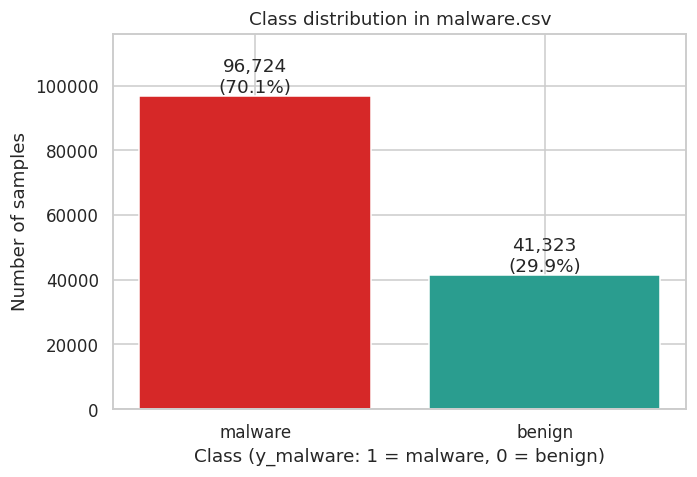

In [ ]:
def plot_class_distribution(y, title, file_name):
    """Bar chart of malware vs benign counts, with the percentage on top of each bar."""
    counts = y.map(LABEL_NAMES).value_counts().reindex(["malware", "benign"]).fillna(0).astype(int)
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    bars = ax.bar(counts.index, counts.values, color=[CLASS_COLORS[name] for name in counts.index])
    for bar, count in zip(bars, counts.values):
        ax.annotate(
            f"{count:,}\n({as_percent(count / counts.sum(), 1)})",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center",
            va="bottom",
        )
    ax.set_title(title)
    ax.set_xlabel("Class (y_malware: 1 = malware, 0 = benign)")
    ax.set_ylabel("Number of samples")
    ax.set_ylim(0, counts.max() * 1.2)
    save_and_show(fig, file_name)


plot_class_distribution(y_malware_all, "Class distribution in malware.csv", "01_class_distribution.png")

**Reading the label from now on**

* `y_malware = 1` → **malware**
* `y_malware = 0` → **benign**

The chart above shows which class is bigger. In the usual version of this dataset, malware is the larger class. That is why, in Section 4, we do **not** give malware extra weight: it is not a rare class that the model might ignore.

## Section 2 — Data cleaning and preprocessing

**Which columns become features?** We decide from the real file, not from a fixed list.

* **`Name` and `md5` are dropped (if present).** `Name` is just a file name and `md5` is a fingerprint that is unique to one exact file. A model could memorise them, but they say nothing about *how a file is built*, so they would not help on new files. Keeping them would let the model "cheat".
* Any other text column where almost every row is different also acts like an ID, so it is dropped too (the notebook prints it if that happens).
* Text columns that really hold numbers (like `"332"`) are turned back into numbers.
* Rows that are exact copies (same features **and** same label) are removed when `DROP_DUPLICATE_ROWS = True`. Otherwise one copy can land in train and another in test, and the test score would look better than it really is.

**Preprocessing plan**

| Column type | Step 1 | Step 2 |
|---|---|---|
| Numeric | Fill gaps with the **median** | — |
| Categorical (text) | Fill gaps with the **most frequent** value | `OrdinalEncoder` (unknown values → `-1`) |

**Why no `StandardScaler`?** XGBoost and Isolation Forest are both **tree-based**. A tree only asks questions like "is this value bigger than 5.3?". Rescaling a feature does not change the answer to those questions, so scaling adds nothing here.

In [ ]:
def drop_target_and_identifiers(df, target_column, identifier_columns):
    """Remove the label and any known ID columns, keeping only candidate PE features."""
    found_identifiers = [column for column in identifier_columns if column in df.columns]
    features = df.drop(columns=[target_column] + found_identifiers)
    return features, found_identifiers


def convert_numeric_text_columns(features):
    """Some CSVs store numbers as text (like "332"). Turn those columns back into numbers."""
    features = features.copy()
    converted_columns = []
    for column in features.columns:
        series = features[column]
        if pd.api.types.is_numeric_dtype(series):
            continue
        as_numbers = pd.to_numeric(series, errors="coerce")
        # We only convert when EVERY non-empty value is a real number, so no information is lost.
        lost_values = as_numbers.isna() & series.notna()
        if series.notna().any() and not lost_values.any():
            features[column] = as_numbers
            converted_columns.append(column)
    return features, converted_columns


def find_id_like_text_columns(features, unique_ratio_limit):
    """Find text columns where almost every row has a different value (they behave like IDs)."""
    id_like_columns = []
    for column in features.columns:
        series = features[column]
        if pd.api.types.is_numeric_dtype(series):
            continue
        if series.nunique(dropna=True) / len(series) > unique_ratio_limit:
            id_like_columns.append(column)
    return id_like_columns


def detect_column_types(features):
    """Split the feature columns into numeric and categorical (text) lists."""
    numeric_columns = [column for column in features.columns if pd.api.types.is_numeric_dtype(features[column])]
    categorical_columns = [column for column in features.columns if column not in numeric_columns]
    return numeric_columns, categorical_columns


def standardise_values(features, numeric_columns, categorical_columns):
    """Make numeric columns float and text columns plain strings; turn infinity into missing values."""
    features = features.copy()
    for column in numeric_columns:
        features[column] = features[column].astype("float64")

    infinite_counts = pd.Series(np.isinf(features[numeric_columns].to_numpy()).sum(axis=0), index=numeric_columns)
    infinite_counts = infinite_counts[infinite_counts > 0]
    if not infinite_counts.empty:
        # The imputer can fill missing values, but it cannot handle infinity, so we convert it.
        print("Infinite values turned into missing values:", infinite_counts.to_dict())
        features[numeric_columns] = features[numeric_columns].replace([np.inf, -np.inf], np.nan)

    for column in categorical_columns:
        # Mixed types (numbers and text in one column) would crash the encoder, so we make everything text.
        text = features[column].astype("object")
        features[column] = text.where(text.isna(), text.astype(str)).astype("object")
    return features


def remove_duplicate_rows(features, target):
    """Drop rows whose features AND label exactly copy an earlier row. Also count label conflicts."""
    combined = features.copy()
    combined["__label__"] = target.to_numpy()
    duplicate_mask = combined.duplicated(keep="first")

    # Same features but different labels: truly ambiguous rows. We keep them and just report them.
    feature_row_hash = pd.util.hash_pandas_object(features, index=False).to_numpy()
    labels_per_feature_row = target.groupby(feature_row_hash).nunique()
    conflicting_feature_rows = int((labels_per_feature_row > 1).sum())

    kept_mask = ~duplicate_mask
    return features.loc[kept_mask], target.loc[kept_mask], int(duplicate_mask.sum()), conflicting_feature_rows


def prepare_features_and_target(df, y, target_column, identifier_columns, unique_ratio_limit, drop_duplicates):
    """Run every cleaning step in order and return clean features, labels and a small report."""
    features, dropped_identifiers = drop_target_and_identifiers(df, target_column, identifier_columns)
    features, converted_columns = convert_numeric_text_columns(features)
    id_like_columns = find_id_like_text_columns(features, unique_ratio_limit)
    features = features.drop(columns=id_like_columns)
    numeric_columns, categorical_columns = detect_column_types(features)
    features = standardise_values(features, numeric_columns, categorical_columns)

    if features.shape[1] == 0:
        raise ValueError("No feature columns are left after cleaning. Check the dataset columns.")

    report = {
        "rows_before_cleaning": len(features),
        "dropped_identifier_columns": dropped_identifiers,
        "dropped_id_like_text_columns": id_like_columns,
        "text_columns_converted_to_numbers": converted_columns,
        "duplicate_rows_removed": 0,
        "feature_rows_with_conflicting_labels": None,
    }
    if drop_duplicates:
        features, y, removed_count, conflicting_count = remove_duplicate_rows(features, y)
        report["duplicate_rows_removed"] = removed_count
        report["feature_rows_with_conflicting_labels"] = conflicting_count
    report["rows_after_cleaning"] = len(features)
    return features, y, numeric_columns, categorical_columns, report

In [ ]:
X, y_malware, numeric_columns, categorical_columns, cleaning_report = prepare_features_and_target(
    raw_df,
    y_malware_all,
    TARGET_COLUMN,
    IDENTIFIER_COLUMNS,
    ID_LIKE_UNIQUE_RATIO,
    DROP_DUPLICATE_ROWS,
)

print("Identifier columns dropped (they name a file, not its structure):",
      cleaning_report["dropped_identifier_columns"] or "none found")
print("Extra ID-like text columns dropped:", cleaning_report["dropped_id_like_text_columns"] or "none")
print("Text columns converted to numbers:", cleaning_report["text_columns_converted_to_numbers"] or "none")
print(f"\nRows before cleaning: {cleaning_report['rows_before_cleaning']:,}")
if DROP_DUPLICATE_ROWS:
    print(f"Exact duplicate rows removed (same features + same label): {cleaning_report['duplicate_rows_removed']:,}")
    print(f"Feature rows that appear with BOTH labels (kept, truly ambiguous): "
          f"{cleaning_report['feature_rows_with_conflicting_labels']:,}")
else:
    print("Duplicate removal is switched off (DROP_DUPLICATE_ROWS = False).")
print(f"Rows after cleaning:  {cleaning_report['rows_after_cleaning']:,}")

print(f"\nFeature columns used by the models: {X.shape[1]}")
print(f"  numeric columns:     {len(numeric_columns)}")
print(f"  categorical columns: {len(categorical_columns)} {categorical_columns if categorical_columns else ''}")
print("\nFeature list:")
print(list(X.columns))

# Constant columns carry no information. We keep them (so the API schema stays simple) but we report them.
constant_columns = [column for column in X.columns if X[column].nunique(dropna=False) <= 1]
print("\nColumns with only one value (no information, kept for a stable schema):", constant_columns or "none")

print(f"\nClass balance after cleaning: malware = {as_percent(y_malware.mean())}, benign = {as_percent(1 - y_malware.mean())}")

Identifier columns dropped (they name a file, not its structure): ['Name', 'md5']
Extra ID-like text columns dropped: none
Text columns converted to numbers: none

Rows before cleaning: 138,047
Exact duplicate rows removed (same features + same label): 33,458
Feature rows that appear with BOTH labels (kept, truly ambiguous): 4
Rows after cleaning:  104,589

Feature columns used by the models: 54
  numeric columns:     54
  categorical columns: 0 

Feature list:
['Machine', 'SizeOfOptionalHeader', 'Characteristics', 'MajorLinkerVersion', 'MinorLinkerVersion', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'SectionAlignment', 'FileAlignment', 'MajorOperatingSystemVersion', 'MinorOperatingSystemVersion', 'MajorImageVersion', 'MinorImageVersion', 'MajorSubsystemVersion', 'MinorSubsystemVersion', 'SizeOfImage', 'SizeOfHeaders', 'CheckSum', 'Subsystem', 'DllCharacteristics', 'SizeOfStackReserve', 'SizeOfStackC

In [ ]:
def build_preprocessor(numeric_columns, categorical_columns):
    """Create (but do not fit) the preprocessing step. It is fitted on training data only in Section 3."""
    transformers = []
    if numeric_columns:
        # The median is not pulled around by extreme values, which PE size features often have.
        transformers.append(
            ("numeric", SimpleImputer(strategy="median", keep_empty_features=True), numeric_columns)
        )
    if categorical_columns:
        # Unknown categories seen later become -1, so the API does not crash on a new value.
        categorical_steps = Pipeline(
            steps=[
                ("fill_missing", SimpleImputer(strategy="most_frequent", keep_empty_features=True)),
                ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
            ]
        )
        transformers.append(("categorical", categorical_steps, categorical_columns))
    if not transformers:
        raise ValueError("There are no feature columns to preprocess.")

    column_transformer = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,  # keep the original feature names, e.g. "ImportsNb"
    )
    # We ask for a DataFrame output so feature names travel with the data into XGBoost and SHAP.
    return column_transformer.set_output(transform="pandas")


preprocessor = build_preprocessor(numeric_columns, categorical_columns)
preprocessor

ColumnTransformer(transformers=[('numeric',
                                 SimpleImputer(keep_empty_features=True,
                                               strategy='median'),
                                 ['Machine', 'SizeOfOptionalHeader',
                                  'Characteristics', 'MajorLinkerVersion',
                                  'MinorLinkerVersion', 'SizeOfCode',
                                  'SizeOfInitializedData',
                                  'SizeOfUninitializedData',
                                  'AddressOfEntryPoint', 'BaseOfCode',
                                  'BaseOfData', 'ImageBase', 'SectionAlignment',
                                  'FileAlignment',
                                  'MajorOperatingSystemVersion',
                                  'MinorOperatingSystemVersion',
                                  'MajorImageVersion', 'MinorImageVersion',
                                  'MajorSubsystemVersion',
                                  'MinorSubsystemVersion', 'SizeOfImage',
                                  'SizeOfHeaders', 'CheckSum', 'Subsystem',
                                  'DllCharacteristics', 'SizeOfStackReserve',
                                  'SizeOfStackCommit', 'SizeOfHeapReserve',
                                  'SizeOfHeapCommit', 'LoaderFlags', ...])],
                  verbose_feature_names_out=False)

## Section 3 — Train / validation / test split

We use **three** separate sets. Each one has one job:

| Set | Share of rows | Job |
|---|---|---|
| **Train** | about 64% | Fit the preprocessor, the classifier, the novelty detector and the novelty-score transformation. |
| **Validation** | about 16% | Check the classifier and **choose the triage thresholds**. |
| **Test** | 20% | Final exam. Used **once**, in Section 8, after the thresholds are frozen. |

Why not one train/test split? If we chose thresholds on the test set, the test score would be tuned to that exact data and would look better than reality. The validation set lets us tune while the test set stays completely unseen.

All splits are **stratified**, so every set keeps the same malware/benign ratio.

In [ ]:
# First split: put 20% aside as the final test set. We will not look at it again until Section 8.
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y_malware, test_size=TEST_SIZE, stratify=y_malware, random_state=RANDOM_STATE
)
# Second split: from the remaining 80%, keep 20% as validation for choosing thresholds.
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=VALIDATION_SIZE_WITHIN_DEV, stratify=y_dev, random_state=RANDOM_STATE
)


def describe_split(split_name, y_part, total_rows):
    """One summary row per split: size, share of all rows and class balance."""
    return {
        "split": split_name,
        "rows": len(y_part),
        "share_of_all_rows": as_percent(len(y_part) / total_rows, 1),
        "malware_percent": as_percent(y_part.mean()),
        "benign_percent": as_percent(1 - y_part.mean()),
    }


split_summary = pd.DataFrame(
    [
        describe_split("train", y_train, len(X)),
        describe_split("validation", y_val, len(X)),
        describe_split("test", y_test, len(X)),
    ]
)
display(split_summary)

,split,rows,share_of_all_rows,malware_percent,benign_percent
0,train,66936,64.0%,60.50%,39.50%
1,validation,16735,16.0%,60.50%,39.50%
2,test,20918,20.0%,60.49%,39.51%


In [ ]:
# The imputer learns its medians from TRAINING rows only. If it looked at validation or test rows,
# information from those sets would leak into the model.
X_train_model = preprocessor.fit_transform(X_train)
X_val_model = preprocessor.transform(X_val)
X_test_model = preprocessor.transform(X_test)
MODEL_FEATURE_NAMES = list(X_train_model.columns)

# Safety checks: every feature must survive preprocessing, and no gaps may be left.
if set(MODEL_FEATURE_NAMES) != set(X.columns):
    raise RuntimeError(
        "Preprocessing changed the feature set. "
        f"Missing: {sorted(set(X.columns) - set(MODEL_FEATURE_NAMES))}, "
        f"extra: {sorted(set(MODEL_FEATURE_NAMES) - set(X.columns))}"
    )
for split_name, split_frame in [("train", X_train_model), ("validation", X_val_model), ("test", X_test_model)]:
    remaining_gaps = int(split_frame.isna().sum().sum())
    if remaining_gaps:
        raise RuntimeError(f"{remaining_gaps} missing values are still left in the {split_name} set after preprocessing.")

print("Model input shapes:")
print("  train:     ", X_train_model.shape)
print("  validation:", X_val_model.shape)
print("  test:      ", X_test_model.shape)
print(f"Model feature count: {len(MODEL_FEATURE_NAMES)}")

Model input shapes:
  train:      (66936, 54)
  validation: (16735, 54)
  test:       (20918, 54)
Model feature count: 54


## Section 4 — XGBoost malware classifier

**What it is:** XGBoost builds many small decision trees, one after another. Each new tree tries to fix the mistakes of the trees before it. The output is a **malware probability** between 0 and 1.

**Why no `scale_pos_weight`?** That setting is for when the positive class (malware) is rare. Here, after `y_malware = 1 - legitimate`, malware is already the larger class. Giving it even more weight would push the model to over-call malware. So we use normal weighting.

**Metrics we report** (positive class = malware). For these standard numbers we use the usual 0.5 cut-off, so every sample is forced into malware or benign. The triage thresholds come later.

| Metric | Plain-English question |
|---|---|
| Accuracy | What share of all samples did we label correctly? |
| Precision | When we say "malware", how often are we right? |
| **Recall** | **How many actual malware samples did we catch?** |
| F1 | One number that balances precision and recall. |
| ROC-AUC | How well does the model rank malware above benign? (1.0 = perfect ranking) |
| PR-AUC | Precision-recall summary that focuses on the malware class. |

For security, **recall** is the key question: every malware sample we miss is one that gets through.

In [ ]:
# We train the classifier on the training set only.
xgb_model = XGBClassifier(**XGB_PARAMS)
training_start = time.perf_counter()
xgb_model.fit(X_train_model, y_train)
print(f"XGBoost trained on {len(X_train_model):,} samples in {time.perf_counter() - training_start:.1f} seconds.")

XGBoost trained on 66,936 samples in 13.9 seconds.


In [ ]:
CLASSIFIER_METRIC_EXPLANATIONS = {
    "accuracy": "Share of all samples labelled correctly.",
    "precision": "When the model says malware, how often is it right?",
    "recall": "How many actual malware samples did we catch?",
    "f1": "Balance of precision and recall in one number.",
    "roc_auc": "How well malware is ranked above benign (1.0 = perfect).",
    "pr_auc": "Precision-recall summary for the malware class.",
}


def predict_malware_probability(model, X_model):
    """Probability of class 1 (malware). We use float64 so threshold checks are exact everywhere."""
    return model.predict_proba(X_model)[:, 1].astype(np.float64)


def compute_classifier_metrics(y_true, malware_probability, cutoff=0.5):
    """Standard classifier metrics. Every sample is forced into malware/benign at `cutoff`."""
    y_true = np.asarray(y_true)
    predicted = (malware_probability >= cutoff).astype(int)
    return {
        "accuracy": accuracy_score(y_true, predicted),
        "precision": precision_score(y_true, predicted, zero_division=0),
        "recall": recall_score(y_true, predicted, zero_division=0),
        "f1": f1_score(y_true, predicted, zero_division=0),
        "roc_auc": roc_auc_score(y_true, malware_probability),
        "pr_auc": average_precision_score(y_true, malware_probability),
    }


def show_classifier_metrics(metrics, title):
    """Print the metrics as a small table with a plain-English meaning next to each one."""
    table = pd.DataFrame(
        {
            "value": [round(float(value), 4) for value in metrics.values()],
            "meaning": [CLASSIFIER_METRIC_EXPLANATIONS[name] for name in metrics],
        },
        index=list(metrics.keys()),
    )
    print(title)
    display(table)


def plot_classifier_diagnostics(y_true, malware_probability, split_name, file_name, cutoff=0.5):
    """Confusion matrix, ROC curve and precision-recall curve side by side."""
    y_true = np.asarray(y_true)
    predicted = (malware_probability >= cutoff).astype(int)
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

    matrix = confusion_matrix(y_true, predicted, labels=[0, 1])
    sns.heatmap(
        matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=["benign", "malware"], yticklabels=["benign", "malware"], ax=axes[0],
    )
    axes[0].set_title(f"Confusion matrix — {split_name} (cut-off {cutoff})")
    axes[0].set_xlabel("Predicted class")
    axes[0].set_ylabel("Actual class")

    false_positive_rate, true_positive_rate, _ = roc_curve(y_true, malware_probability)
    axes[1].plot(false_positive_rate, true_positive_rate, color="#1d3557",
                 label=f"XGBoost (ROC-AUC = {roc_auc_score(y_true, malware_probability):.4f})")
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guessing")
    axes[1].set_title(f"ROC curve — {split_name}")
    axes[1].set_xlabel("False positive rate (benign flagged as malware)")
    axes[1].set_ylabel("True positive rate (malware caught = recall)")
    axes[1].legend(loc="lower right")

    precision_values, recall_values, _ = precision_recall_curve(y_true, malware_probability)
    malware_share = float(np.mean(y_true))
    axes[2].plot(recall_values, precision_values, color="#1d3557",
                 label=f"XGBoost (PR-AUC = {average_precision_score(y_true, malware_probability):.4f})")
    axes[2].axhline(malware_share, linestyle="--", color="grey",
                    label=f"Always say malware (precision {malware_share:.2f})")
    axes[2].set_title(f"Precision-recall curve — {split_name}")
    axes[2].set_xlabel("Recall (share of malware caught)")
    axes[2].set_ylabel("Precision (share of malware alerts that are correct)")
    axes[2].legend(loc="lower left")
    save_and_show(fig, file_name)

XGBoost on the VALIDATION set (cut-off 0.5):


,value,meaning
accuracy,0.9941,Share of all samples labelled correctly.
precision,0.9964,"When the model says malware, how often is it r..."
recall,0.9939,How many actual malware samples did we catch?
f1,0.9952,Balance of precision and recall in one number.
roc_auc,0.9996,How well malware is ranked above benign (1.0 =...
pr_auc,0.9998,Precision-recall summary for the malware class.


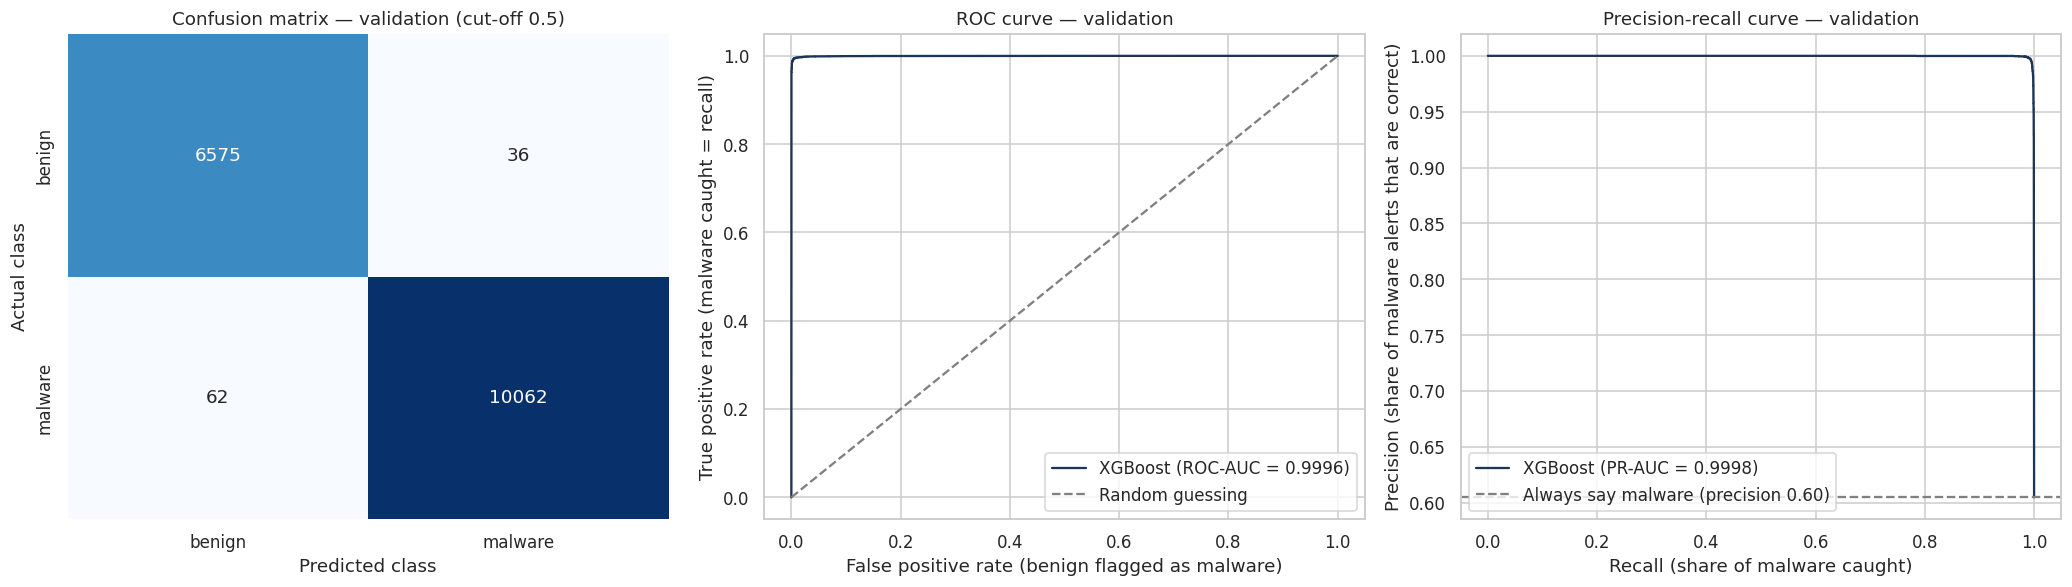

Security reading: recall = 0.9939. Out of every 1,000 malware samples in validation, the classifier catches about 994.
Precision = 0.9964. Out of every 1,000 malware alerts, about 996 are real malware.
Note: malware is the larger class here, so the 'always say malware' baseline already has high precision. That is why ROC-AUC and PR-AUC are shown next to the simple scores.


In [ ]:
# We check the classifier on the VALIDATION set. The test set stays untouched.
val_malware_probability = predict_malware_probability(xgb_model, X_val_model)
val_classifier_metrics = compute_classifier_metrics(y_val, val_malware_probability)
show_classifier_metrics(val_classifier_metrics, "XGBoost on the VALIDATION set (cut-off 0.5):")
plot_classifier_diagnostics(y_val, val_malware_probability, "validation", "04_classifier_validation.png")

print(
    f"Security reading: recall = {val_classifier_metrics['recall']:.4f}. Out of every 1,000 malware samples "
    f"in validation, the classifier catches about {round(1000 * val_classifier_metrics['recall'])}."
)
print(
    f"Precision = {val_classifier_metrics['precision']:.4f}. Out of every 1,000 malware alerts, "
    f"about {round(1000 * val_classifier_metrics['precision'])} are real malware."
)
print(
    "Note: malware is the larger class here, so the 'always say malware' baseline already has high "
    "precision. That is why ROC-AUC and PR-AUC are shown next to the simple scores."
)

## Section 5 — Novelty detector (Isolation Forest)

**The question it answers:** *"Does this sample look structurally unusual compared with the training data?"*

**How Isolation Forest works:** it keeps cutting the data at random places. A normal sample sits in a crowd, so it takes many cuts to separate it. An unusual sample sits far from the crowd, so a few cuts isolate it. **Fewer cuts = more unusual.**

Important choices:

* It is fitted **only on the training features** (malware and benign together). It never sees validation or test data while learning. It models the overall training feature distribution.
* It does **not** use labels. It only learns what "normal-looking" PE structure is in our training data.
* This is **not** zero-day detection. A high novelty score only means "this looks different from what we trained on".

In [ ]:
# We fit Isolation Forest on the TRAINING features only.
iforest = IsolationForest(**IFOREST_PARAMS)
novelty_fit_start = time.perf_counter()
iforest.fit(X_train_model)
print(f"Isolation Forest fitted on {len(X_train_model):,} training samples in "
      f"{time.perf_counter() - novelty_fit_start:.1f} seconds.")

Isolation Forest fitted on 66,936 training samples in 1.4 seconds.


### Turning the raw anomaly score into `novelty_score` (0 = very familiar, 1 = highly novel)

Isolation Forest gives a raw score that is hard to read. We turn it into a **percentile against the training data**:

> `novelty_score = 0.95` means "this sample is more unusual than 95% of the training samples".

How we do it, without leaking any information:

1. Take the raw anomaly scores of the **training** samples only.
2. Fit a `QuantileTransformer` on those scores. It learns the training percentiles (an *empirical distribution*).
3. For any new sample, look up where its raw score falls among the training scores. Clip the result to `[0, 1]`.

We never use test-set minimum/maximum values and we never use labels here. The fitted transformer is saved in Section 11, so the API computes the score in exactly the same way.

*Small technical note:* the percentiles come from the same training rows the forest was built on. Each tree only uses 256 random rows, so any single training row is inside very few trees. The bias from this is tiny. Section 5's validation check below confirms the scores behave as expected on unseen data.

In [ ]:
def novelty_raw_score(novelty_detector, X_model):
    """Raw anomaly score where HIGHER = MORE unusual (sklearn's score_samples is the opposite, so we flip it)."""
    return -novelty_detector.score_samples(X_model)


def compute_novelty_score(novelty_detector, novelty_transformer, X_model):
    """novelty_score in [0, 1]: the share of training samples that look more normal than this sample."""
    raw_scores = novelty_raw_score(novelty_detector, X_model)
    percentiles = novelty_transformer.transform(raw_scores.reshape(-1, 1)).ravel()
    return np.clip(percentiles, 0.0, 1.0)


# We learn the percentile mapping from TRAINING anomaly scores only.
train_novelty_raw = novelty_raw_score(iforest, X_train_model)
novelty_transformer = QuantileTransformer(
    n_quantiles=min(1000, len(train_novelty_raw)),
    output_distribution="uniform",
    subsample=len(train_novelty_raw),  # use every training score, no random subsampling
    random_state=RANDOM_STATE,
)
novelty_transformer.fit(train_novelty_raw.reshape(-1, 1))

train_novelty_score = compute_novelty_score(iforest, novelty_transformer, X_train_model)
val_novelty_score = compute_novelty_score(iforest, novelty_transformer, X_val_model)
print("novelty_score summary:")
display(
    pd.DataFrame(
        {"train": pd.Series(train_novelty_score).describe(), "validation": pd.Series(val_novelty_score).describe()}
    ).round(4)
)

novelty_score summary:


,train,validation
count,66936.0000,16735.0000
mean,0.4994,0.5000
std,0.2892,0.2879
min,0.0000,0.0000
25%,0.2477,0.2477
50%,0.5003,0.5015
75%,0.7500,0.7506
max,1.0000,0.9998


In [ ]:
# Sanity checks. If validation looks like training, about 5% of it should score 0.95 or more.
reference_novelty_threshold = STARTING_THRESHOLDS["novelty_threshold"]
print(f"Share with novelty_score >= {reference_novelty_threshold}:")
print(f"  train:      {as_percent(np.mean(train_novelty_score >= reference_novelty_threshold))}")
print(f"  validation: {as_percent(np.mean(val_novelty_score >= reference_novelty_threshold))}")

# contamination=0.05 makes Isolation Forest call its 5% most unusual TRAINING samples outliers (-1).
# Our novelty_score >= 0.95 rule is the same "top 5% most unusual" idea, so the two should mostly agree.
val_iforest_flags = iforest.predict(X_val_model) == -1
print(f"\nIsolation Forest's own outlier flag (contamination = {IFOREST_PARAMS['contamination']}):")
print(f"  train flag rate:      {as_percent(np.mean(iforest.predict(X_train_model) == -1))}")
print(f"  validation flag rate: {as_percent(np.mean(val_iforest_flags))}")
print(f"  agreement with novelty_score >= {reference_novelty_threshold} on validation: "
      f"{as_percent(np.mean(val_iforest_flags == (val_novelty_score >= reference_novelty_threshold)))}")

Share with novelty_score >= 0.95:
  train:      4.99%
  validation: 4.88%

Isolation Forest's own outlier flag (contamination = 0.05):
  train flag rate:      4.99%
  validation flag rate: 4.88%
  agreement with novelty_score >= 0.95 on validation: 100.00%


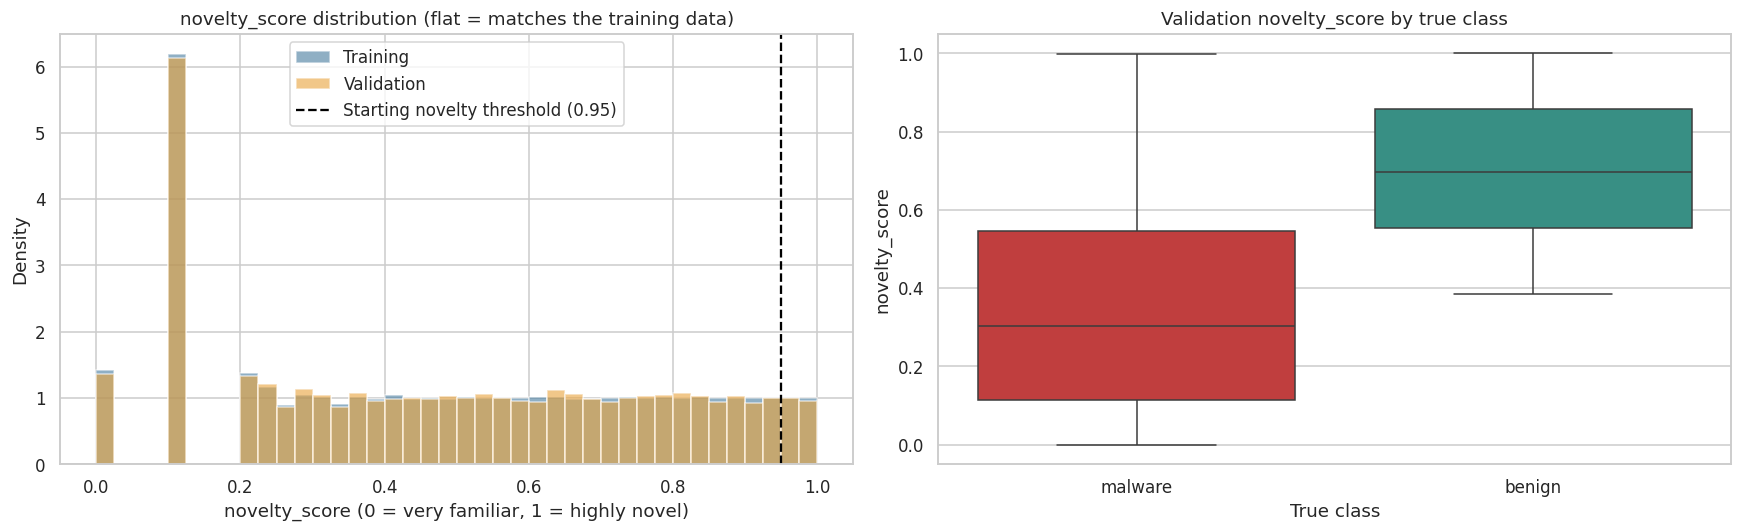

In [ ]:
def plot_novelty_overview(train_scores, val_scores, y_val_part, reference_threshold, file_name):
    """Left: novelty distribution for train vs validation. Right: validation novelty by class."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    bins = np.linspace(0, 1, 41)
    axes[0].hist(train_scores, bins=bins, density=True, alpha=0.6, color="#457b9d", label="Training")
    axes[0].hist(val_scores, bins=bins, density=True, alpha=0.6, color="#e9a23b", label="Validation")
    axes[0].axvline(reference_threshold, linestyle="--", color="black",
                    label=f"Starting novelty threshold ({reference_threshold})")
    axes[0].set_title("novelty_score distribution (flat = matches the training data)")
    axes[0].set_xlabel("novelty_score (0 = very familiar, 1 = highly novel)")
    axes[0].set_ylabel("Density")
    axes[0].legend()

    frame = pd.DataFrame({"novelty_score": val_scores, "class": pd.Series(np.asarray(y_val_part)).map(LABEL_NAMES)})
    sns.boxplot(data=frame, x="class", y="novelty_score", hue="class", order=["malware", "benign"],
                palette=CLASS_COLORS, legend=False, ax=axes[1])
    axes[1].set_title("Validation novelty_score by true class")
    axes[1].set_xlabel("True class")
    axes[1].set_ylabel("novelty_score")
    save_and_show(fig, file_name)


plot_novelty_overview(train_novelty_score, val_novelty_score, y_val, reference_novelty_threshold,
                      "05_novelty_overview.png")

## Section 6 — Threshold selection (validation set only)

The starting values are `malware_threshold = 0.85`, `benign_threshold = 0.15` and `novelty_threshold = 0.95`. They are **not** automatically final. We test a small grid around them on the **validation set**.

For each combination we measure:

* **coverage** = (MALWARE + BENIGN) / total → how much work is done automatically
* **abstention_rate** = NEEDS_ANALYSIS / total → how much goes to a human analyst
* **selective_error_rate** = wrong MALWARE/BENIGN verdicts / number of MALWARE/BENIGN verdicts → how often the *confident* decisions are wrong

We do **not** optimise plain accuracy. Our selection rule (written down before looking at the results):

1. **Analyst budget:** keep only combinations with `abstention_rate ≤ MAX_ABSTENTION_RATE` (10% by default).
2. Inside the budget, find the **lowest selective error**.
3. Error rates within about **two standard errors** of that best value count as "near-best". A smaller difference could just be luck in the validation set.
4. Among the near-best combinations, pick the one **closest to the starting values**. If there is still a tie, pick the higher coverage.

In plain words: **we keep the designed starting values unless the validation data shows clear evidence that they make more mistakes than necessary.** If it does, we move only as far as needed.

Why not simply pick the highest coverage? The validation set comes from the *same* distribution as the training data, so it contains almost no truly unfamiliar samples. It cannot show the benefit of sending unusual samples to an analyst. A coverage-hungry rule would therefore always loosen the novelty threshold and the benign threshold, and quietly switch off the safety route. The notebook still prints that highest-coverage option, for transparency. **The test set is never used here.**

In [ ]:
def triage_verdicts_fast(malware_probability, novelty_score, malware_threshold, benign_threshold, novelty_threshold):
    """The same verdict rules as the official engine (Section 7), but for whole arrays at once.

    We only use this fast version for the threshold search (thousands of samples x 125 combinations).
    Section 7 checks that it gives exactly the same answers as the official engine.
    """
    probability = np.asarray(malware_probability, dtype=np.float64)
    novelty = np.asarray(novelty_score, dtype=np.float64)
    looks_familiar = novelty < novelty_threshold
    verdicts = np.full(probability.shape, "NEEDS_ANALYSIS", dtype=object)
    verdicts[(probability >= malware_threshold) & looks_familiar] = "MALWARE"
    verdicts[(probability <= benign_threshold) & looks_familiar] = "BENIGN"
    return verdicts


def compute_triage_metrics(y_true, verdicts):
    """Count verdicts and measure coverage, abstention and the quality of the confident decisions."""
    y_true = np.asarray(y_true)
    verdicts = np.asarray(verdicts)
    total = len(y_true)
    is_malware_verdict = verdicts == "MALWARE"
    is_benign_verdict = verdicts == "BENIGN"
    is_needs_analysis = verdicts == "NEEDS_ANALYSIS"
    confident = is_malware_verdict | is_benign_verdict
    confident_count = int(confident.sum())

    false_malware_alarms = int((is_malware_verdict & (y_true == 0)).sum())   # benign called MALWARE
    missed_malware = int((is_benign_verdict & (y_true == 1)).sum())          # malware called BENIGN
    true_malware_verdicts = int((is_malware_verdict & (y_true == 1)).sum())
    true_benign_verdicts = int((is_benign_verdict & (y_true == 0)).sum())
    actual_malware = int((y_true == 1).sum())
    confident_errors = false_malware_alarms + missed_malware

    return {
        "total": total,
        "malware_verdicts": int(is_malware_verdict.sum()),
        "benign_verdicts": int(is_benign_verdict.sum()),
        "needs_analysis_verdicts": int(is_needs_analysis.sum()),
        "coverage": confident_count / total,
        "abstention_rate": int(is_needs_analysis.sum()) / total,
        "selective_error_rate": confident_errors / confident_count if confident_count else np.nan,
        "confident_errors": confident_errors,
        "false_malware_alarms": false_malware_alarms,
        "missed_malware_called_benign": missed_malware,
        "malware_sent_to_analysis": int((is_needs_analysis & (y_true == 1)).sum()),
        "malware_verdict_precision": (
            true_malware_verdicts / int(is_malware_verdict.sum()) if is_malware_verdict.any() else np.nan
        ),
        "malware_verdict_recall": true_malware_verdicts / actual_malware if actual_malware else np.nan,
        "benign_verdict_precision": (
            true_benign_verdicts / int(is_benign_verdict.sum()) if is_benign_verdict.any() else np.nan
        ),
    }


def distance_from_start(malware_threshold, benign_threshold, novelty_threshold):
    """How far a combination is from the starting values (used only to break ties)."""
    return (
        abs(malware_threshold - STARTING_THRESHOLDS["malware_threshold"])
        + abs(benign_threshold - STARTING_THRESHOLDS["benign_threshold"])
        + abs(novelty_threshold - STARTING_THRESHOLDS["novelty_threshold"])
    )


def evaluate_threshold_grid(y_true, malware_probability, novelty_score):
    """Score every threshold combination in the grid on the given (validation) data."""
    rows = []
    for malware_threshold, benign_threshold, novelty_threshold in itertools.product(
        MALWARE_THRESHOLD_GRID, BENIGN_THRESHOLD_GRID, NOVELTY_THRESHOLD_GRID
    ):
        verdicts = triage_verdicts_fast(
            malware_probability, novelty_score, malware_threshold, benign_threshold, novelty_threshold
        )
        rows.append(
            {
                "malware_threshold": malware_threshold,
                "benign_threshold": benign_threshold,
                "novelty_threshold": novelty_threshold,
                **compute_triage_metrics(y_true, verdicts),
                "distance_from_start": distance_from_start(malware_threshold, benign_threshold, novelty_threshold),
            }
        )
    return pd.DataFrame(rows)


def select_thresholds(grid_results, max_abstention_rate):
    """Apply the written-down selection rule. Returns (chosen row, record of how it was chosen)."""
    within_budget = grid_results[grid_results["abstention_rate"] <= max_abstention_rate]
    if within_budget.empty:
        chosen = grid_results.sort_values(["abstention_rate", "selective_error_rate", "distance_from_start"]).iloc[0]
        record = {
            "fallback_used": True,
            "reason": "No combination fits the analyst budget, so the one with the lowest abstention rate was chosen.",
            "max_abstention_rate": max_abstention_rate,
        }
        print("WARNING:", record["reason"], "Consider a larger MAX_ABSTENTION_RATE.")
        return chosen, record

    best_row = within_budget.sort_values(["selective_error_rate", "coverage"], ascending=[True, False]).iloc[0]
    best_error = float(best_row["selective_error_rate"])
    confident_decisions = int(best_row["malware_verdicts"] + best_row["benign_verdicts"])
    # Two standard errors of an error rate; at least one error, so a zero-error result is not over-trusted.
    noise_band = max(2.0 * math.sqrt(best_error * (1.0 - best_error) / confident_decisions), 1.0 / confident_decisions)
    near_best = within_budget[within_budget["selective_error_rate"] <= best_error + noise_band]
    chosen = near_best.sort_values(
        ["distance_from_start", "coverage", "selective_error_rate"], ascending=[True, False, True]
    ).iloc[0]
    # Shown for transparency only: the near-best option that would send the fewest samples to analysts.
    highest_coverage = near_best.sort_values(["coverage", "distance_from_start"], ascending=[False, True]).iloc[0]
    record = {
        "fallback_used": False,
        "rule": (
            "Within the analyst budget (abstention_rate <= max_abstention_rate), keep combinations whose "
            "selective error is within ~2 standard errors of the best one, then pick the one closest to the "
            "starting values; ties go to the higher coverage."
        ),
        "max_abstention_rate": max_abstention_rate,
        "combinations_tested": int(len(grid_results)),
        "combinations_within_budget": int(len(within_budget)),
        "best_selective_error_within_budget": best_error,
        "noise_band": noise_band,
        "combinations_near_best": int(len(near_best)),
        "starting_values_are_near_best": bool(float(chosen["distance_from_start"]) == 0.0),
        "highest_coverage_near_best_option": {
            name: float(highest_coverage[name])
            for name in ["malware_threshold", "benign_threshold", "novelty_threshold", "coverage", "selective_error_rate"]
        },
    }
    return chosen, record

In [ ]:
# We score all 125 combinations on the VALIDATION set only.
grid_results = evaluate_threshold_grid(y_val, val_malware_probability, val_novelty_score)
chosen_combination, selection_record = select_thresholds(grid_results, MAX_ABSTENTION_RATE)
grid_results.to_csv(REPORTS_DIR / "threshold_grid_validation.csv", index=False)

# We also measure the starting values separately, so we can compare them with the chosen ones.
starting_metrics = compute_triage_metrics(
    y_val, triage_verdicts_fast(val_malware_probability, val_novelty_score, **STARTING_THRESHOLDS)
)
chosen_metrics = {key: chosen_combination[key] for key in starting_metrics}

comparison_columns = ["coverage", "abstention_rate", "selective_error_rate", "confident_errors",
                      "false_malware_alarms", "missed_malware_called_benign",
                      "malware_verdict_precision", "malware_verdict_recall"]
comparison = pd.DataFrame(
    {
        "starting values": {name: starting_metrics[name] for name in comparison_columns},
        "chosen on validation": {name: chosen_metrics[name] for name in comparison_columns},
    }
)
print("Chosen thresholds:",
      {name: float(chosen_combination[name]) for name in ["malware_threshold", "benign_threshold", "novelty_threshold"]})
if not selection_record["fallback_used"]:
    print(f"Combinations inside the analyst budget: {selection_record['combinations_within_budget']} "
          f"of {selection_record['combinations_tested']}")
    print(f"Best selective error inside the budget: {as_percent(selection_record['best_selective_error_within_budget'], 3)} "
          f"(near-best = within {as_percent(selection_record['noise_band'], 3)} of it: "
          f"{selection_record['combinations_near_best']} combinations)")
    if selection_record["starting_values_are_near_best"]:
        print("-> The starting values are already near-best on validation, so we keep them.")
    else:
        print("-> The starting values make clearly more mistakes than the best option, "
              "so we move to the closest near-best combination.")
    print("For transparency, the near-best option with the highest coverage would have been:",
          selection_record["highest_coverage_near_best_option"])
display(comparison.round(5))

print("\nTop 10 combinations inside the analyst budget (lowest selective error first):")
top_in_budget = grid_results[grid_results["abstention_rate"] <= MAX_ABSTENTION_RATE].sort_values(
    ["selective_error_rate", "coverage"], ascending=[True, False]
)
display(
    top_in_budget[["malware_threshold", "benign_threshold", "novelty_threshold", "coverage",
                   "abstention_rate", "selective_error_rate", "confident_errors"]].head(10).round(5)
)

Chosen thresholds: {'malware_threshold': 0.85, 'benign_threshold': 0.05, 'novelty_threshold': 0.95}
Combinations inside the analyst budget: 100 of 125
Best selective error inside the budget: 0.154% (near-best = within 0.061% of it: 13 combinations)
-> The starting values make clearly more mistakes than the best option, so we move to the closest near-best combination.
For transparency, the near-best option with the highest coverage would have been: {'malware_threshold': 0.85, 'benign_threshold': 0.05, 'novelty_threshold': 0.99, 'coverage': 0.9760979982073499, 'selective_error_rate': 0.00202020202020202}


,starting values,chosen on validation
coverage,0.94234,0.93762
abstention_rate,0.05766,0.06238
selective_error_rate,0.00292,0.00204
confident_errors,46.00000,32.00000
false_malware_alarms,11.00000,11.00000
missed_malware_called_benign,35.00000,21.00000
malware_verdict_precision,0.99888,0.99888
malware_verdict_recall,0.96849,0.96849



Top 10 combinations inside the analyst budget (lowest selective error first):


,malware_threshold,benign_threshold,novelty_threshold,coverage,abstention_rate,selective_error_rate,confident_errors
104,0.95,0.05,0.99,0.97126,0.02874,0.00154,25
103,0.95,0.05,0.97,0.95279,0.04721,0.00157,25
101,0.95,0.05,0.93,0.91431,0.08569,0.00157,24
102,0.95,0.05,0.95,0.93331,0.06669,0.00160,25
78,0.90,0.05,0.97,0.95572,0.04428,0.00181,29
76,0.90,0.05,0.93,0.91712,0.08288,0.00182,28
79,0.90,0.05,0.99,0.97448,0.02552,0.00184,30
77,0.90,0.05,0.95,0.93612,0.06388,0.00185,29
53,0.85,0.05,0.97,0.95728,0.04272,0.00200,32
51,0.85,0.05,0.93,0.91849,0.08151,0.00202,31


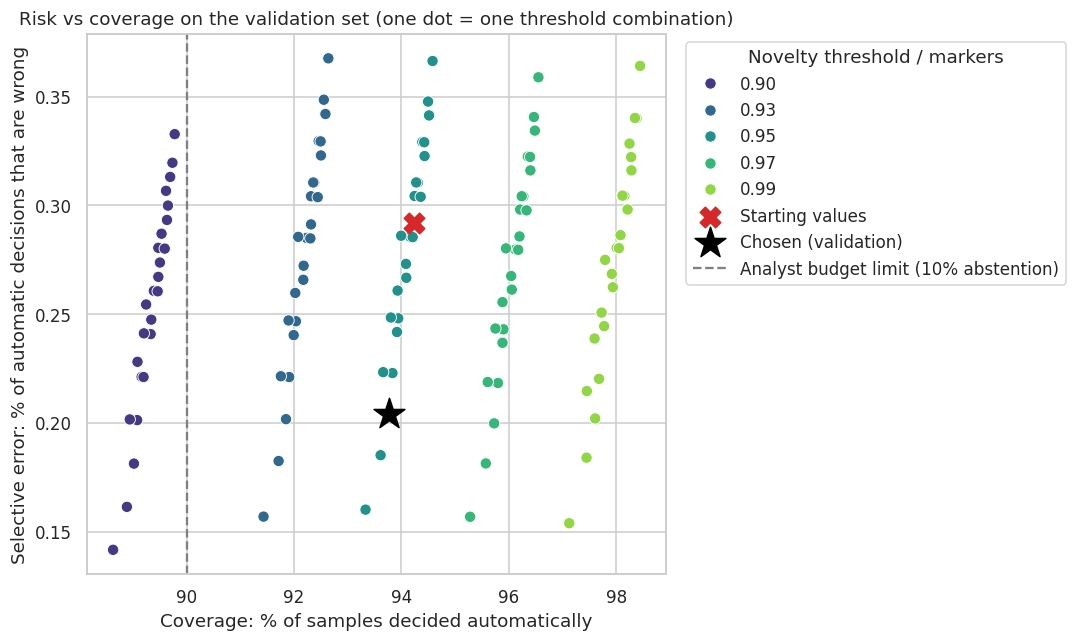

In [ ]:
def plot_risk_coverage(grid_results, chosen, starting, max_abstention_rate, file_name):
    """Every threshold combination as a dot: automatic coverage (x) vs error of confident decisions (y)."""
    frame = grid_results.assign(
        coverage_percent=100 * grid_results["coverage"],
        selective_error_percent=100 * grid_results["selective_error_rate"],
        novelty_threshold_label=grid_results["novelty_threshold"].map("{:.2f}".format),
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.scatterplot(data=frame, x="coverage_percent", y="selective_error_percent",
                    hue="novelty_threshold_label", palette="viridis", s=55, ax=ax)
    ax.scatter(100 * starting["coverage"], 100 * starting["selective_error_rate"], marker="X", s=180,
               color="#d62828", label="Starting values", zorder=5)
    ax.scatter(100 * chosen["coverage"], 100 * chosen["selective_error_rate"], marker="*", s=450,
               color="black", label="Chosen (validation)", zorder=6)
    ax.axvline(100 * (1 - max_abstention_rate), linestyle="--", color="grey",
               label=f"Analyst budget limit ({as_percent(max_abstention_rate, 0)} abstention)")
    ax.set_title("Risk vs coverage on the validation set (one dot = one threshold combination)")
    ax.set_xlabel("Coverage: % of samples decided automatically")
    ax.set_ylabel("Selective error: % of automatic decisions that are wrong")
    ax.legend(title="Novelty threshold / markers", bbox_to_anchor=(1.02, 1), loc="upper left")
    save_and_show(fig, file_name)


plot_risk_coverage(grid_results, chosen_combination, starting_metrics, MAX_ABSTENTION_RATE, "06_risk_coverage.png")

### Are high-novelty samples actually harder for the classifier?

This is an honest check of *why* we route novel samples to analysts. We group validation samples by novelty score and look at the classifier's normal error rate (0.5 cut-off) in each group. If unusual samples have more errors, sending them to NEEDS_ANALYSIS is supported by the data. If not, the novelty route is still a safety policy for unfamiliar inputs, but the notebook will say so plainly.

,samples,errors,error_rate
novelty_band,,,
0.00-0.50,8345,10,0.00120
0.50-0.80,5063,59,0.01165
0.80-0.90,1703,13,0.00763
0.90-0.95,807,8,0.00991
0.95-0.99,653,5,0.00766
0.99-1.00,164,3,0.01829


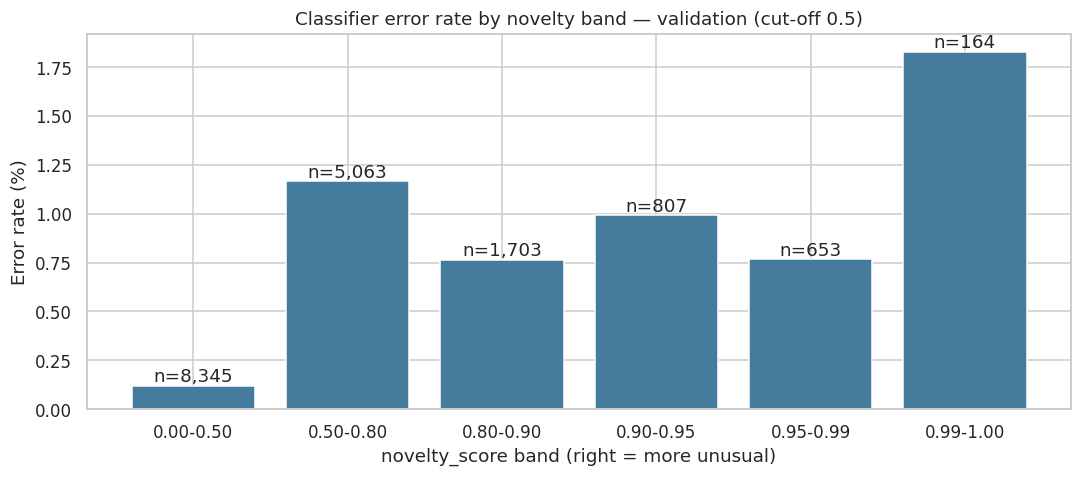

Validation: novelty_score >= 0.95 for 817 samples (4.88%).
  classifier error rate on NOVEL samples:    0.979%
  classifier error rate on FAMILIAR samples: 0.565%
  -> The classifier makes MORE mistakes on unusual samples. This supports sending them to NEEDS_ANALYSIS.


In [ ]:
NOVELTY_BAND_EDGES = [0.0, 0.5, 0.8, 0.9, 0.95, 0.99, np.inf]
NOVELTY_BAND_LABELS = ["0.00-0.50", "0.50-0.80", "0.80-0.90", "0.90-0.95", "0.95-0.99", "0.99-1.00"]


def error_rate_by_novelty_band(y_true, malware_probability, novelty_score, cutoff=0.5):
    """Classifier error rate (forced binary at `cutoff`) inside each novelty band."""
    wrong = (malware_probability >= cutoff).astype(int) != np.asarray(y_true)
    bands = pd.cut(novelty_score, bins=NOVELTY_BAND_EDGES, labels=NOVELTY_BAND_LABELS, right=False)
    table = (
        pd.DataFrame({"novelty_band": bands, "wrong": wrong})
        .groupby("novelty_band", observed=False)["wrong"]
        .agg(samples="size", errors="sum")
    )
    table["error_rate"] = table["errors"] / table["samples"].replace(0, np.nan)
    return table


def plot_error_by_novelty(band_table, split_name, file_name):
    """Bar chart of the classifier error rate per novelty band, with sample counts on the bars."""
    fig, ax = plt.subplots(figsize=(10, 4.5))
    bars = ax.bar(band_table.index.astype(str), 100 * band_table["error_rate"].fillna(0), color="#457b9d")
    for bar, samples in zip(bars, band_table["samples"]):
        ax.annotate(f"n={samples:,}", (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha="center", va="bottom")
    ax.set_title(f"Classifier error rate by novelty band — {split_name} (cut-off 0.5)")
    ax.set_xlabel("novelty_score band (right = more unusual)")
    ax.set_ylabel("Error rate (%)")
    save_and_show(fig, file_name)


def compare_novel_vs_familiar(y_true, malware_probability, novelty_score, novelty_threshold, split_name):
    """Print the classifier error rate for novel vs familiar samples in plain English."""
    wrong = (malware_probability >= 0.5).astype(int) != np.asarray(y_true)
    is_novel = novelty_score >= novelty_threshold
    novel_error = wrong[is_novel].mean() if is_novel.any() else np.nan
    familiar_error = wrong[~is_novel].mean() if (~is_novel).any() else np.nan
    print(f"{split_name}: novelty_score >= {novelty_threshold} for {int(is_novel.sum()):,} samples "
          f"({as_percent(is_novel.mean())}).")
    print(f"  classifier error rate on NOVEL samples:    {as_percent(novel_error, 3)}")
    print(f"  classifier error rate on FAMILIAR samples: {as_percent(familiar_error, 3)}")
    if np.isnan(novel_error) or np.isnan(familiar_error):
        print("  Not enough samples in one of the groups to compare.")
    elif novel_error > familiar_error:
        print("  -> The classifier makes MORE mistakes on unusual samples. This supports sending them to NEEDS_ANALYSIS.")
    else:
        print("  -> Unusual samples were NOT harder for the classifier here. The novelty route is then a safety policy "
              "for unfamiliar inputs, not an accuracy booster on this data.")
    return novel_error, familiar_error


val_band_table = error_rate_by_novelty_band(y_val, val_malware_probability, val_novelty_score)
display(val_band_table.assign(error_rate=lambda table: table["error_rate"].round(5)))
plot_error_by_novelty(val_band_table, "validation", "06_error_by_novelty_validation.png")
val_novel_error, val_familiar_error = compare_novel_vs_familiar(
    y_val, val_malware_probability, val_novelty_score, float(chosen_combination["novelty_threshold"]), "Validation"
)

In [ ]:
# We FREEZE the thresholds now. From here on they never change, and the test set has not been touched.
TRIAGE_SETTINGS = {
    "malware_threshold": float(chosen_combination["malware_threshold"]),
    "benign_threshold": float(chosen_combination["benign_threshold"]),
    "novelty_threshold": float(chosen_combination["novelty_threshold"]),
    "high_confidence_margin": float(HIGH_CONFIDENCE_MARGIN),
    "high_confidence_max_novelty": float(HIGH_CONFIDENCE_MAX_NOVELTY),
}
thresholds_record = {
    **TRIAGE_SETTINGS,
    "chosen_using": "validation set only (the test set was never used for tuning)",
    "starting_values": STARTING_THRESHOLDS,
    "grid": {
        "malware_threshold": MALWARE_THRESHOLD_GRID,
        "benign_threshold": BENIGN_THRESHOLD_GRID,
        "novelty_threshold": NOVELTY_THRESHOLD_GRID,
    },
    "selection": selection_record,
    "validation_metrics_at_chosen_thresholds": chosen_metrics,
    "confidence_rule_note": "HIGH/MEDIUM/LOW is a transparent rule, not a calibrated probability.",
}
save_json(thresholds_record, ARTIFACTS_DIR / ARTIFACT_FILE_NAMES["thresholds"])
print("\nFROZEN triage settings:")
for name, value in TRIAGE_SETTINGS.items():
    print(f"  {name:<28} {value}")

Saved /content/drive/MyDrive/UNKNOWN_FIRST/ml_package/artifacts/thresholds.json

FROZEN triage settings:
  malware_threshold            0.85
  benign_threshold             0.05
  novelty_threshold            0.95
  high_confidence_margin       0.5
  high_confidence_max_novelty  0.8


## Section 7 — Triage engine

The rules (using the frozen thresholds):

```
IF malware_probability >= malware_threshold AND novelty_score < novelty_threshold  → MALWARE
IF malware_probability <= benign_threshold  AND novelty_score < novelty_threshold  → BENIGN
ELSE                                                                               → NEEDS_ANALYSIS
```

**Confidence** is a simple, transparent rule. It is **not** a calibrated statistical probability:

| Confidence | When |
|---|---|
| **HIGH** | Strong classifier evidence **and** low novelty: the probability is at least halfway from its threshold to the extreme (0 or 1), **and** `novelty_score < 0.80`. |
| **MEDIUM** | A MALWARE or BENIGN verdict that is not HIGH (moderately strong evidence, still familiar). |
| **LOW** | NEEDS_ANALYSIS: high novelty or an ambiguous probability. |

We write these rules into a small file, `ml_package/triage_rules.py`. The notebook **and** the API both import that same file, so the rules can never drift apart.

In [ ]:
%%writefile "{TRIAGE_RULES_PATH}"
"""
UNKNOWN-FIRST triage rules.

This file is shared by the training notebook and by the API package, so both
always use exactly the same rules to turn scores into a verdict.

Verdicts:
    MALWARE         - confident malware AND the sample looks familiar
    BENIGN          - confident benign AND the sample looks familiar
    NEEDS_ANALYSIS  - ambiguous probability and/or structurally novel sample

Confidence (HIGH / MEDIUM / LOW) is a simple, transparent rule.
It is NOT a calibrated statistical probability.
"""
import math
from numbers import Real

MALWARE = "MALWARE"
BENIGN = "BENIGN"
NEEDS_ANALYSIS = "NEEDS_ANALYSIS"
VERDICTS = (MALWARE, BENIGN, NEEDS_ANALYSIS)

HIGH = "HIGH"
MEDIUM = "MEDIUM"
LOW = "LOW"
CONFIDENCE_LEVELS = (HIGH, MEDIUM, LOW)

# Default confidence-rule settings. The saved thresholds.json passes its own values.
DEFAULT_HIGH_CONFIDENCE_MARGIN = 0.5
DEFAULT_HIGH_CONFIDENCE_MAX_NOVELTY = 0.80


def _as_unit_interval(name, value):
    """Check that a value is a real number between 0 and 1 and return it as a float."""
    if isinstance(value, bool) or not isinstance(value, Real):
        raise TypeError(f"{name} must be a number between 0 and 1, got {type(value).__name__}.")
    value = float(value)
    if not math.isfinite(value) or not 0.0 <= value <= 1.0:
        raise ValueError(f"{name} must be between 0 and 1, got {value}.")
    return value


def _check_thresholds(malware_threshold, benign_threshold, novelty_threshold):
    """Make sure the three thresholds make sense together."""
    malware_threshold = _as_unit_interval("malware_threshold", malware_threshold)
    benign_threshold = _as_unit_interval("benign_threshold", benign_threshold)
    novelty_threshold = _as_unit_interval("novelty_threshold", novelty_threshold)
    if not 0.0 < benign_threshold < malware_threshold < 1.0:
        raise ValueError(
            "Thresholds must satisfy 0 < benign_threshold < malware_threshold < 1, "
            f"got benign_threshold={benign_threshold}, malware_threshold={malware_threshold}."
        )
    if novelty_threshold == 0.0:
        raise ValueError("novelty_threshold must be above 0, otherwise every sample counts as novel.")
    return malware_threshold, benign_threshold, novelty_threshold


def assign_confidence(verdict, malware_probability, novelty_score, malware_threshold, benign_threshold,
                      high_confidence_margin=DEFAULT_HIGH_CONFIDENCE_MARGIN,
                      high_confidence_max_novelty=DEFAULT_HIGH_CONFIDENCE_MAX_NOVELTY):
    """HIGH / MEDIUM / LOW from a transparent rule (NOT a calibrated probability).

    LOW    : the verdict is NEEDS_ANALYSIS (high novelty or ambiguous probability).
    HIGH   : the probability is at least `high_confidence_margin` of the way from its threshold
             to the extreme (1 for MALWARE, 0 for BENIGN) AND novelty < `high_confidence_max_novelty`.
    MEDIUM : a MALWARE or BENIGN verdict that is not HIGH.
    """
    margin = _as_unit_interval("high_confidence_margin", high_confidence_margin)
    max_novelty = _as_unit_interval("high_confidence_max_novelty", high_confidence_max_novelty)
    if verdict == NEEDS_ANALYSIS:
        return LOW
    if verdict == MALWARE:
        evidence_strength = (malware_probability - malware_threshold) / (1.0 - malware_threshold)
    elif verdict == BENIGN:
        evidence_strength = (benign_threshold - malware_probability) / benign_threshold
    else:
        raise ValueError(f"Unknown verdict {verdict!r}. Expected one of {VERDICTS}.")
    clearly_familiar = novelty_score < max_novelty
    return HIGH if (evidence_strength >= margin and clearly_familiar) else MEDIUM


def triage_sample(malware_probability, novelty_score, malware_threshold, benign_threshold, novelty_threshold,
                  high_confidence_margin=DEFAULT_HIGH_CONFIDENCE_MARGIN,
                  high_confidence_max_novelty=DEFAULT_HIGH_CONFIDENCE_MAX_NOVELTY):
    """Turn one sample's two scores into (verdict, confidence).

    probability >= malware_threshold AND novelty < novelty_threshold -> MALWARE
    probability <= benign_threshold  AND novelty < novelty_threshold -> BENIGN
    anything else                                                    -> NEEDS_ANALYSIS
    """
    probability = _as_unit_interval("malware_probability", malware_probability)
    novelty = _as_unit_interval("novelty_score", novelty_score)
    malware_threshold, benign_threshold, novelty_threshold = _check_thresholds(
        malware_threshold, benign_threshold, novelty_threshold
    )

    looks_familiar = novelty < novelty_threshold
    if probability >= malware_threshold and looks_familiar:
        verdict = MALWARE
    elif probability <= benign_threshold and looks_familiar:
        verdict = BENIGN
    else:
        verdict = NEEDS_ANALYSIS

    confidence = assign_confidence(
        verdict, probability, novelty, malware_threshold, benign_threshold,
        high_confidence_margin, high_confidence_max_novelty,
    )
    return verdict, confidence


def needs_analysis_reason(malware_probability, novelty_score, malware_threshold, benign_threshold, novelty_threshold):
    """Explain in words why a sample went to NEEDS_ANALYSIS (empty text if it did not)."""
    is_novel = novelty_score >= novelty_threshold
    is_ambiguous = benign_threshold < malware_probability < malware_threshold
    if is_novel and is_ambiguous:
        return "structurally novel AND ambiguous malware probability"
    if is_novel:
        return "structurally novel compared with the training data"
    if is_ambiguous:
        return "ambiguous malware probability"
    return ""


def shap_direction(shap_value):
    """Positive SHAP pushes toward malware (class 1); negative pushes toward benign."""
    if shap_value > 0:
        return "towards_malware"
    if shap_value < 0:
        return "towards_benign"
    return "neutral"

Writing /content/drive/MyDrive/UNKNOWN_FIRST/ml_package/triage_rules.py


In [ ]:
# We import the rules file we just wrote. Our own package is created inside this notebook,
# so it cannot be imported in the Section 0 import cell.
# Python can import a folder as a package even before __init__.py exists; Section 13 adds that file.
importlib.invalidate_caches()
import ml_package.triage_rules as triage_rules  # noqa: E402

triage_rules = importlib.reload(triage_rules)  # makes re-runs pick up the newest version of the file

if list(triage_rules.VERDICTS) != VERDICT_ORDER:
    raise RuntimeError(f"Verdict names in triage_rules.py {triage_rules.VERDICTS} do not match {VERDICT_ORDER}.")

# Small hand-made tests. Each case has an obvious correct answer.
unit_test_thresholds = {
    "malware_threshold": 0.85, "benign_threshold": 0.15, "novelty_threshold": 0.95,
    "high_confidence_margin": 0.5, "high_confidence_max_novelty": 0.80,
}
unit_test_cases = [
    # (probability, novelty, expected verdict, expected confidence, why)
    (0.99, 0.10, "MALWARE", "HIGH", "very sure malware, very familiar"),
    (0.87, 0.10, "MALWARE", "MEDIUM", "only just past the malware threshold"),
    (0.99, 0.90, "MALWARE", "MEDIUM", "sure malware but only somewhat familiar"),
    (0.01, 0.10, "BENIGN", "HIGH", "very sure benign, very familiar"),
    (0.12, 0.10, "BENIGN", "MEDIUM", "only just past the benign threshold"),
    (0.50, 0.10, "NEEDS_ANALYSIS", "LOW", "ambiguous probability"),
    (0.99, 0.97, "NEEDS_ANALYSIS", "LOW", "sure malware but structurally novel"),
    (0.01, 0.99, "NEEDS_ANALYSIS", "LOW", "sure benign but structurally novel"),
]
for probability, novelty, expected_verdict, expected_confidence, why in unit_test_cases:
    result = triage_rules.triage_sample(probability, novelty, **unit_test_thresholds)
    if result != (expected_verdict, expected_confidence):
        raise AssertionError(f"Case '{why}' gave {result}, expected {(expected_verdict, expected_confidence)}.")
    print(f"[OK] p={probability:.2f}, novelty={novelty:.2f} -> {result[0]:<15} {result[1]:<7} ({why})")

# Bad inputs must be rejected loudly, never silently accepted.
for bad_probability in [1.5, -0.1, float("nan"), "0.9"]:
    try:
        triage_rules.triage_sample(bad_probability, 0.1, **unit_test_thresholds)
    except (TypeError, ValueError) as error:
        print(f"[OK] rejected malware_probability={bad_probability!r}: {error}")
    else:
        raise AssertionError(f"triage_sample accepted an invalid probability: {bad_probability!r}")

[OK] p=0.99, novelty=0.10 -> MALWARE         HIGH    (very sure malware, very familiar)
[OK] p=0.87, novelty=0.10 -> MALWARE         MEDIUM  (only just past the malware threshold)
[OK] p=0.99, novelty=0.90 -> MALWARE         MEDIUM  (sure malware but only somewhat familiar)
[OK] p=0.01, novelty=0.10 -> BENIGN          HIGH    (very sure benign, very familiar)
[OK] p=0.12, novelty=0.10 -> BENIGN          MEDIUM  (only just past the benign threshold)
[OK] p=0.50, novelty=0.10 -> NEEDS_ANALYSIS  LOW     (ambiguous probability)
[OK] p=0.99, novelty=0.97 -> NEEDS_ANALYSIS  LOW     (sure malware but structurally novel)
[OK] p=0.01, novelty=0.99 -> NEEDS_ANALYSIS  LOW     (sure benign but structurally novel)
[OK] rejected malware_probability=1.5: malware_probability must be between 0 and 1, got 1.5.
[OK] rejected malware_probability=-0.1: malware_probability must be between 0 and 1, got -0.1.
[OK] rejected malware_probability=nan: malware_probability must be between 0 and 1, got nan.
[OK] rej

In [ ]:
# The whole system as one function: raw PE features in, verdicts out.
# It uses the OFFICIAL triage_sample for every row, exactly like the API will.
SYSTEM = {
    "preprocessor": preprocessor,
    "classifier": xgb_model,
    "novelty_detector": iforest,
    "novelty_transformer": novelty_transformer,
}


def run_triage_pipeline(X_raw, system, triage_settings):
    """Raw features -> preprocessing -> malware probability + novelty score -> official triage rules."""
    X_model = system["preprocessor"].transform(X_raw)
    probability = predict_malware_probability(system["classifier"], X_model)
    novelty = compute_novelty_score(system["novelty_detector"], system["novelty_transformer"], X_model)
    decisions = [triage_rules.triage_sample(p, n, **triage_settings) for p, n in zip(probability, novelty)]
    return pd.DataFrame(
        {
            "malware_probability": probability,
            "novelty_score": novelty,
            "verdict": [verdict for verdict, _ in decisions],
            "confidence": [confidence for _, confidence in decisions],
        },
        index=X_raw.index,
    )


def confidence_breakdown(results, y_true):
    """For each verdict + confidence level: how many samples, and how many automatic decisions were wrong."""
    frame = results.assign(actual=np.asarray(y_true))
    frame["wrong_decision"] = ((frame["verdict"] == "MALWARE") & (frame["actual"] == 0)) | (
        (frame["verdict"] == "BENIGN") & (frame["actual"] == 1)
    )
    table = frame.groupby(["verdict", "confidence"]).agg(
        samples=("wrong_decision", "size"), wrong_decisions=("wrong_decision", "sum")
    )
    table["error_rate"] = table["wrong_decisions"] / table["samples"]
    # NEEDS_ANALYSIS makes no automatic decision, so an error rate does not apply.
    table.loc[table.index.get_level_values("verdict") == "NEEDS_ANALYSIS", "error_rate"] = np.nan
    return table


# Check 1: the official engine and the fast grid-search version agree on EVERY validation sample.
val_results = run_triage_pipeline(X_val, SYSTEM, TRIAGE_SETTINGS)
fast_val_verdicts = triage_verdicts_fast(
    val_malware_probability, val_novelty_score,
    TRIAGE_SETTINGS["malware_threshold"], TRIAGE_SETTINGS["benign_threshold"], TRIAGE_SETTINGS["novelty_threshold"],
)
disagreements = int((val_results["verdict"].to_numpy() != fast_val_verdicts).sum())
if disagreements:
    raise AssertionError(f"The official engine and the fast version disagree on {disagreements} validation samples.")
print(f"[OK] Official engine and fast grid version agree on all {len(val_results):,} validation samples.")

# Check 2: does HIGH confidence really have fewer mistakes than MEDIUM? (A sanity check, not a calibration.)
print("\nVerdict / confidence breakdown on VALIDATION:")
display(confidence_breakdown(val_results, y_val).round(5))

[OK] Official engine and fast grid version agree on all 16,735 validation samples.

Verdict / confidence breakdown on VALIDATION:


samples  wrong_decisions  error_rate
verdict        confidence                                      
BENIGN         HIGH           4107               10     0.00243
               MEDIUM         1768               11     0.00622
MALWARE        HIGH           9013                4     0.00044
               MEDIUM          803                7     0.00872
NEEDS_ANALYSIS LOW            1044                0         NaN

## Section 8 — Final test evaluation

The thresholds were frozen in Section 6. Now, **for the first and only time**, we run the complete system on the **test set**.

Two kinds of results:

* **Classifier metrics**: the XGBoost model alone, forced to answer malware/benign at 0.5.
* **Triage metrics**: the full system with the third verdict.

[OK] Thresholds match the frozen thresholds.json. Running the full system on the TEST set...
XGBoost on the TEST set (cut-off 0.5):


,value,meaning
accuracy,0.9922,Share of all samples labelled correctly.
precision,0.9952,"When the model says malware, how often is it r..."
recall,0.9918,How many actual malware samples did we catch?
f1,0.9935,Balance of precision and recall in one number.
roc_auc,0.9995,How well malware is ranked above benign (1.0 =...
pr_auc,0.9997,Precision-recall summary for the malware class.


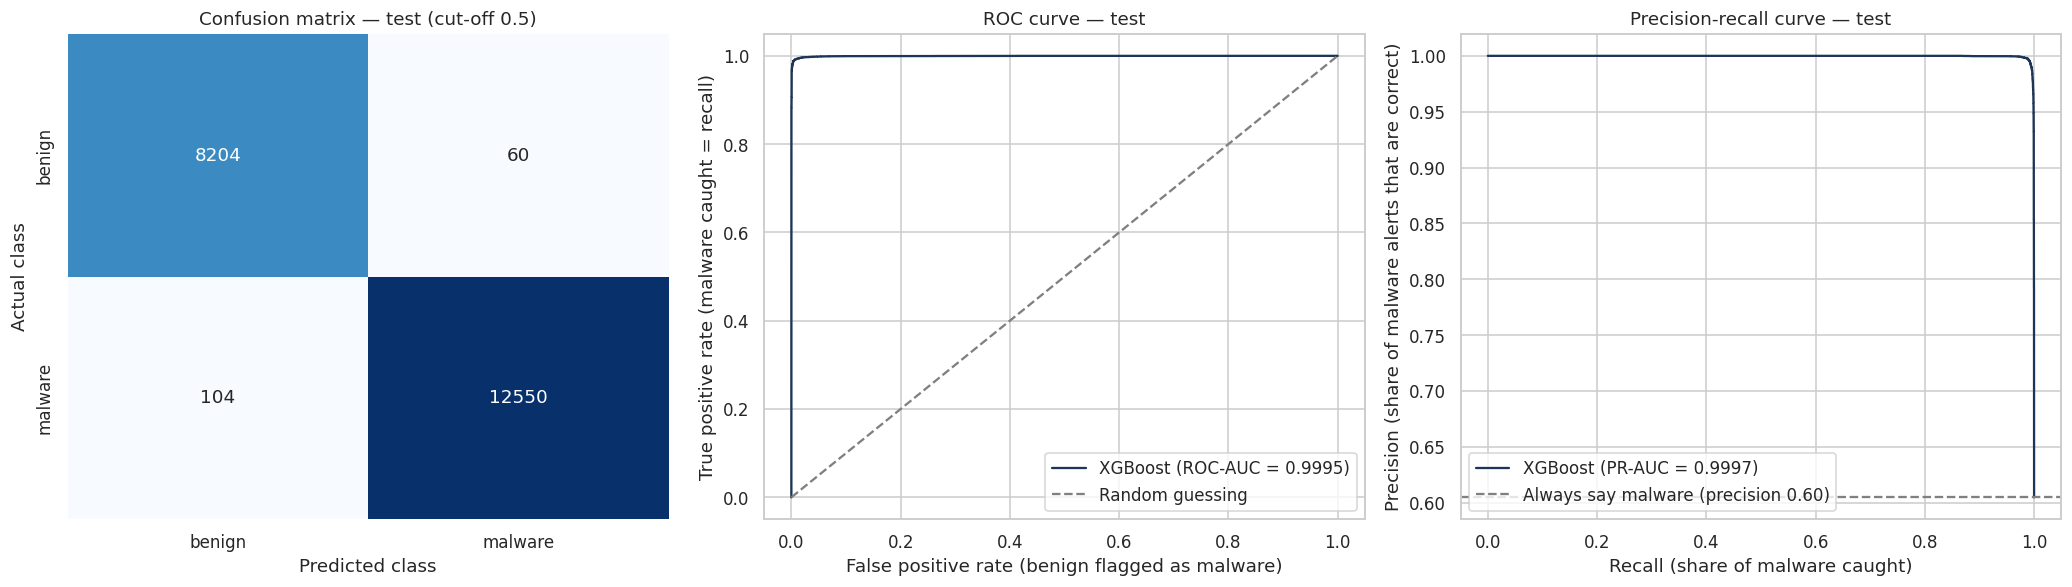

In [ ]:
# We prove the thresholds are frozen: the file on disk must match what we are about to use.
saved_thresholds = load_json(ARTIFACTS_DIR / ARTIFACT_FILE_NAMES["thresholds"])
for name, value in TRIAGE_SETTINGS.items():
    if not math.isclose(saved_thresholds[name], value):
        raise RuntimeError(f"Threshold '{name}' changed after freezing: saved {saved_thresholds[name]}, now {value}.")
print("[OK] Thresholds match the frozen thresholds.json. Running the full system on the TEST set...")

test_results = run_triage_pipeline(X_test, SYSTEM, TRIAGE_SETTINGS)
test_results["y_malware"] = y_test.to_numpy()
test_results.to_csv(REPORTS_DIR / "test_predictions.csv", index_label="row_id")

# Part 1: the classifier alone.
test_malware_probability = test_results["malware_probability"].to_numpy()
test_classifier_metrics = compute_classifier_metrics(y_test, test_malware_probability)
show_classifier_metrics(test_classifier_metrics, "XGBoost on the TEST set (cut-off 0.5):")
plot_classifier_diagnostics(y_test, test_malware_probability, "test", "08_classifier_test.png")

In [ ]:
TRIAGE_METRIC_EXPLANATIONS = {
    "total": "Number of test samples.",
    "malware_verdicts": "Samples that got an automatic MALWARE verdict.",
    "benign_verdicts": "Samples that got an automatic BENIGN verdict.",
    "needs_analysis_verdicts": "Samples sent to a human analyst.",
    "coverage": "Share of samples decided automatically (MALWARE or BENIGN).",
    "abstention_rate": "Share of samples sent to NEEDS_ANALYSIS.",
    "selective_error_rate": "Among automatic decisions only: the share that were wrong.",
    "confident_errors": "Number of wrong automatic decisions.",
    "false_malware_alarms": "Benign files wrongly called MALWARE.",
    "missed_malware_called_benign": "Malware wrongly called BENIGN (the most dangerous mistake).",
    "malware_sent_to_analysis": "Malware that was not decided automatically but sent to an analyst.",
    "malware_verdict_precision": "When the system says MALWARE, how often is it really malware?",
    "malware_verdict_recall": "Out of all real malware, how much got an automatic MALWARE verdict?",
    "benign_verdict_precision": "When the system says BENIGN, how often is it really benign?",
}

# Part 2: the full triage system.
test_triage_metrics = compute_triage_metrics(y_test, test_results["verdict"])
triage_table = pd.DataFrame(
    {
        "value": [
            f"{value:,}" if isinstance(value, int) else f"{value:.5f}" for value in test_triage_metrics.values()
        ],
        "meaning": [TRIAGE_METRIC_EXPLANATIONS[name] for name in test_triage_metrics],
    },
    index=list(test_triage_metrics.keys()),
)
print("Full triage system on the TEST set:")
display(triage_table)

actual_test_malware = int(y_test.sum())
print(f"MALWARE-verdict precision = {test_triage_metrics['malware_verdict_precision']:.5f}")
print("  -> When the system says MALWARE, this is the share that really is malware.")
print(f"MALWARE-verdict recall    = {test_triage_metrics['malware_verdict_recall']:.5f}")
print("  -> Out of all real malware in the test set, this share got an automatic MALWARE verdict.")
print(f"     The rest of the malware either went to an analyst ({test_triage_metrics['malware_sent_to_analysis']:,}) "
      f"or was wrongly called BENIGN ({test_triage_metrics['missed_malware_called_benign']:,}).")
print(f"Malware NOT auto-cleared as benign: "
      f"{as_percent(1 - test_triage_metrics['missed_malware_called_benign'] / actual_test_malware, 3)} of all test malware.")

Full triage system on the TEST set:


,value,meaning
total,"20,918",Number of test samples.
malware_verdicts,"12,214",Samples that got an automatic MALWARE verdict.
benign_verdicts,"7,301",Samples that got an automatic BENIGN verdict.
needs_analysis_verdicts,"1,403",Samples sent to a human analyst.
coverage,0.93293,Share of samples decided automatically (MALWAR...
abstention_rate,0.06707,Share of samples sent to NEEDS_ANALYSIS.
selective_error_rate,0.00297,Among automatic decisions only: the share that...
confident_errors,58,Number of wrong automatic decisions.
false_malware_alarms,24,Benign files wrongly called MALWARE.
missed_malware_called_benign,34,Malware wrongly called BENIGN (the most danger...


MALWARE-verdict precision = 0.99804
  -> When the system says MALWARE, this is the share that really is malware.
MALWARE-verdict recall    = 0.96333
  -> Out of all real malware in the test set, this share got an automatic MALWARE verdict.
     The rest of the malware either went to an analyst (430) or was wrongly called BENIGN (34).
Malware NOT auto-cleared as benign: 99.731% of all test malware.


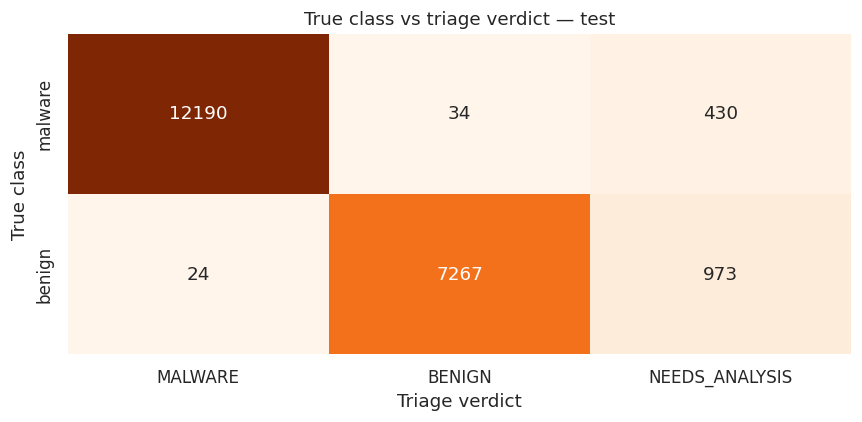

Classifier forced to decide every sample (cut-off 0.5): 164 wrong out of 20,918 (0.784%).
Triage system: 58 wrong automatic decisions out of 19,515 (selective error 0.297%), plus 1,403 samples sent to analysts.

Verdict / confidence breakdown on TEST:


samples  wrong_decisions  error_rate
verdict        confidence                                      
BENIGN         HIGH           5124               22     0.00429
               MEDIUM         2177               12     0.00551
MALWARE        HIGH          11199               12     0.00107
               MEDIUM         1015               12     0.01182
NEEDS_ANALYSIS LOW            1403                0         NaN

,samples,errors,error_rate
novelty_band,,,
0.00-0.50,10394,35,0.00337
0.50-0.80,6326,91,0.01439
0.80-0.90,2106,20,0.00950
0.90-0.95,1028,11,0.01070
0.95-0.99,838,5,0.00597
0.99-1.00,226,2,0.00885


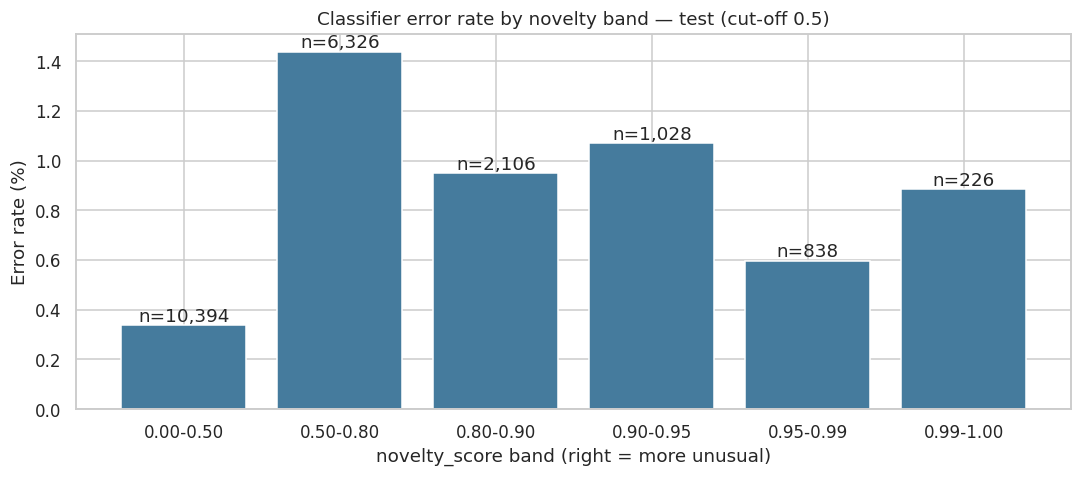

Test: novelty_score >= 0.95 for 1,064 samples (5.09%).
  classifier error rate on NOVEL samples:    0.658%
  classifier error rate on FAMILIAR samples: 0.791%
  -> Unusual samples were NOT harder for the classifier here. The novelty route is then a safety policy for unfamiliar inputs, not an accuracy booster on this data.


In [ ]:
def plot_verdicts_vs_truth(results, y_true, split_name, file_name):
    """Heatmap: true class (rows) against the system verdict (columns)."""
    frame = pd.DataFrame({"actual": pd.Series(np.asarray(y_true)).map(LABEL_NAMES), "verdict": results["verdict"].to_numpy()})
    table = pd.crosstab(frame["actual"], frame["verdict"]).reindex(
        index=["malware", "benign"], columns=VERDICT_ORDER, fill_value=0
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(table, annot=True, fmt="d", cmap="Oranges", cbar=False, ax=ax)
    ax.set_title(f"True class vs triage verdict — {split_name}")
    ax.set_xlabel("Triage verdict")
    ax.set_ylabel("True class")
    save_and_show(fig, file_name)


plot_verdicts_vs_truth(test_results, y_test, "test", "08_verdicts_vs_truth_test.png")

# Forced binary decision vs triage: what does the third verdict buy us?
forced_wrong = int(((test_malware_probability >= 0.5).astype(int) != y_test.to_numpy()).sum())
print(f"Classifier forced to decide every sample (cut-off 0.5): {forced_wrong:,} wrong out of {len(y_test):,} "
      f"({as_percent(forced_wrong / len(y_test), 3)}).")
print(f"Triage system: {test_triage_metrics['confident_errors']:,} wrong automatic decisions out of "
      f"{test_triage_metrics['malware_verdicts'] + test_triage_metrics['benign_verdicts']:,} "
      f"(selective error {as_percent(test_triage_metrics['selective_error_rate'], 3)}), "
      f"plus {test_triage_metrics['needs_analysis_verdicts']:,} samples sent to analysts.")

print("\nVerdict / confidence breakdown on TEST:")
display(confidence_breakdown(test_results, y_test).round(5))

test_band_table = error_rate_by_novelty_band(y_test, test_malware_probability, test_results["novelty_score"].to_numpy())
display(test_band_table.assign(error_rate=lambda table: table["error_rate"].round(5)))
plot_error_by_novelty(test_band_table, "test", "08_error_by_novelty_test.png")
test_novel_error, test_familiar_error = compare_novel_vs_familiar(
    y_test, test_malware_probability, test_results["novelty_score"].to_numpy(),
    TRIAGE_SETTINGS["novelty_threshold"], "Test",
)

## Section 9 — Synthetic novelty stress test

> ⚠️ **Synthetic novelty stress test — not real malware transformation.**

Our dataset has no labels for "unseen malware families", so we cannot measure real-world novelty directly. Instead, we run a **controlled experiment**:

1. Take a random held-out subset of test samples.
2. Push selected PE features away from normal, by `k` **training** standard deviations (`k = 0, 1, 2, 3, 5`; `k = 0` is the unchanged control group).
   * **Section entropy** features are shifted but kept inside the valid range **0–8 bits**. Because of that hard ceiling, entropy has less room to move than counts do, so a smaller response there is expected.
   * **Import count** and **resource count/size** features are shifted and rounded to whole numbers where they are counts.
3. Run the complete system and measure how many perturbed samples get a **high novelty score**.

**What this shows:** that the novelty detector *responds* to controlled structural changes.
**What this does NOT show:** these edited rows are not real malware, and this is **not** proof of real-world zero-day detection.

In [ ]:
STRESS_TEST_LABEL = "Synthetic novelty stress test — not real malware transformation."
print("=" * 80)
print(STRESS_TEST_LABEL.upper())
print("=" * 80)

# Training statistics decide how big one "step" is for each feature. We never use test statistics here.
train_feature_stats = pd.DataFrame(
    {
        "std": X_train[numeric_columns].std(),
        "min": X_train[numeric_columns].min(),
        "is_integer": X_train[numeric_columns].apply(lambda column: bool(np.all(np.mod(column.dropna(), 1) == 0))),
    }
)


def find_stress_test_groups(numeric_feature_names, feature_stats):
    """Pick the feature groups to perturb, using only columns that really exist and actually vary."""
    lower_names = {name: name.lower() for name in numeric_feature_names}
    candidate_groups = {
        "Section entropy": [n for n in numeric_feature_names if "section" in lower_names[n] and "entropy" in lower_names[n]],
        "Import counts": [n for n in numeric_feature_names if "import" in lower_names[n]],
        "Resource counts and sizes": [
            n for n in numeric_feature_names if "resource" in lower_names[n] and "entropy" not in lower_names[n]
        ],
    }
    usable_groups = {}
    for group_name, columns in candidate_groups.items():
        movable = [column for column in columns if feature_stats.loc[column, "std"] > 0]
        not_movable = sorted(set(columns) - set(movable))
        if not_movable:
            print(f"{group_name}: skipping columns with no spread in training data: {not_movable}")
        if movable:
            usable_groups[group_name] = movable
        else:
            print(f"{group_name}: no usable matching columns in this dataset, so this scenario is skipped.")

    if not usable_groups:
        # Fallback: perturb the 5 numeric features XGBoost uses most.
        importance = pd.Series(xgb_model.feature_importances_, index=MODEL_FEATURE_NAMES)
        movable_numeric = [n for n in numeric_feature_names if feature_stats.loc[n, "std"] > 0]
        top_features = importance[movable_numeric].sort_values(ascending=False).head(5).index.tolist()
        print("No named feature groups found. Using the 5 most important numeric features instead:", top_features)
        usable_groups["Top-5 important features"] = top_features

    if len(usable_groups) > 1:
        all_columns = set().union(*usable_groups.values())
        usable_groups["All groups combined"] = [n for n in numeric_feature_names if n in all_columns]
    return usable_groups


def apply_controlled_shift(X_raw, columns, shift_in_std, feature_stats):
    """Increase the chosen features by `shift_in_std` training standard deviations, keeping values valid."""
    shifted = X_raw.copy()
    for column in columns:
        new_values = shifted[column] + shift_in_std * feature_stats.loc[column, "std"]
        if "entropy" in column.lower():
            new_values = new_values.clip(0.0, 8.0)  # byte entropy can only be between 0 and 8 bits
        if feature_stats.loc[column, "is_integer"]:
            new_values = new_values.round()  # counts stay whole numbers
        shifted[column] = new_values
    return shifted


stress_groups = find_stress_test_groups(numeric_columns, train_feature_stats)
for group_name, columns in stress_groups.items():
    print(f"{group_name}: {columns}")

SYNTHETIC NOVELTY STRESS TEST — NOT REAL MALWARE TRANSFORMATION.
Section entropy: ['SectionsMeanEntropy', 'SectionsMinEntropy', 'SectionsMaxEntropy']
Import counts: ['ImportsNbDLL', 'ImportsNb', 'ImportsNbOrdinal']
Resource counts and sizes: ['ResourcesNb', 'ResourcesMeanSize', 'ResourcesMinSize', 'ResourcesMaxSize']
All groups combined: ['SectionsMeanEntropy', 'SectionsMinEntropy', 'SectionsMaxEntropy', 'ImportsNbDLL', 'ImportsNb', 'ImportsNbOrdinal', 'ResourcesNb', 'ResourcesMeanSize', 'ResourcesMinSize', 'ResourcesMaxSize']


In [ ]:
# We use a random subset of held-out test rows. Thresholds are already frozen, so nothing is tuned here.
stress_base = X_test.sample(n=min(STRESS_TEST_SAMPLE_SIZE, len(X_test)), random_state=RANDOM_STATE)
stress_rows = []
for scenario_name, scenario_columns in stress_groups.items():
    for shift in STRESS_TEST_SHIFTS_IN_STD:
        perturbed = apply_controlled_shift(stress_base, scenario_columns, shift, train_feature_stats)
        results = run_triage_pipeline(perturbed, SYSTEM, TRIAGE_SETTINGS)
        stress_rows.append(
            {
                "scenario": scenario_name,
                "shift_in_std": shift,
                "features_changed": len(scenario_columns),
                "high_novelty_percent": 100 * np.mean(results["novelty_score"] >= TRIAGE_SETTINGS["novelty_threshold"]),
                "mean_novelty_score": results["novelty_score"].mean(),
                "needs_analysis_percent": 100 * np.mean(results["verdict"] == "NEEDS_ANALYSIS"),
            }
        )
stress_results = pd.DataFrame(stress_rows)
stress_results.to_csv(REPORTS_DIR / "synthetic_novelty_stress_test.csv", index=False)
print(STRESS_TEST_LABEL)
display(stress_results.round(3))

Synthetic novelty stress test — not real malware transformation.


,scenario,shift_in_std,features_changed,high_novelty_percent,mean_novelty_score,needs_analysis_percent
0,Section entropy,0,3,4.85,0.502,6.15
1,Section entropy,1,3,5.25,0.589,7.80
2,Section entropy,2,3,6.30,0.623,12.05
3,Section entropy,3,3,6.95,0.648,14.35
4,Section entropy,5,3,7.60,0.663,16.20
5,Import counts,0,3,4.85,0.502,6.15
6,Import counts,1,3,5.65,0.613,7.75
7,Import counts,2,3,7.35,0.660,9.70
8,Import counts,3,3,11.00,0.743,13.15
9,Import counts,5,3,25.15,0.879,27.10


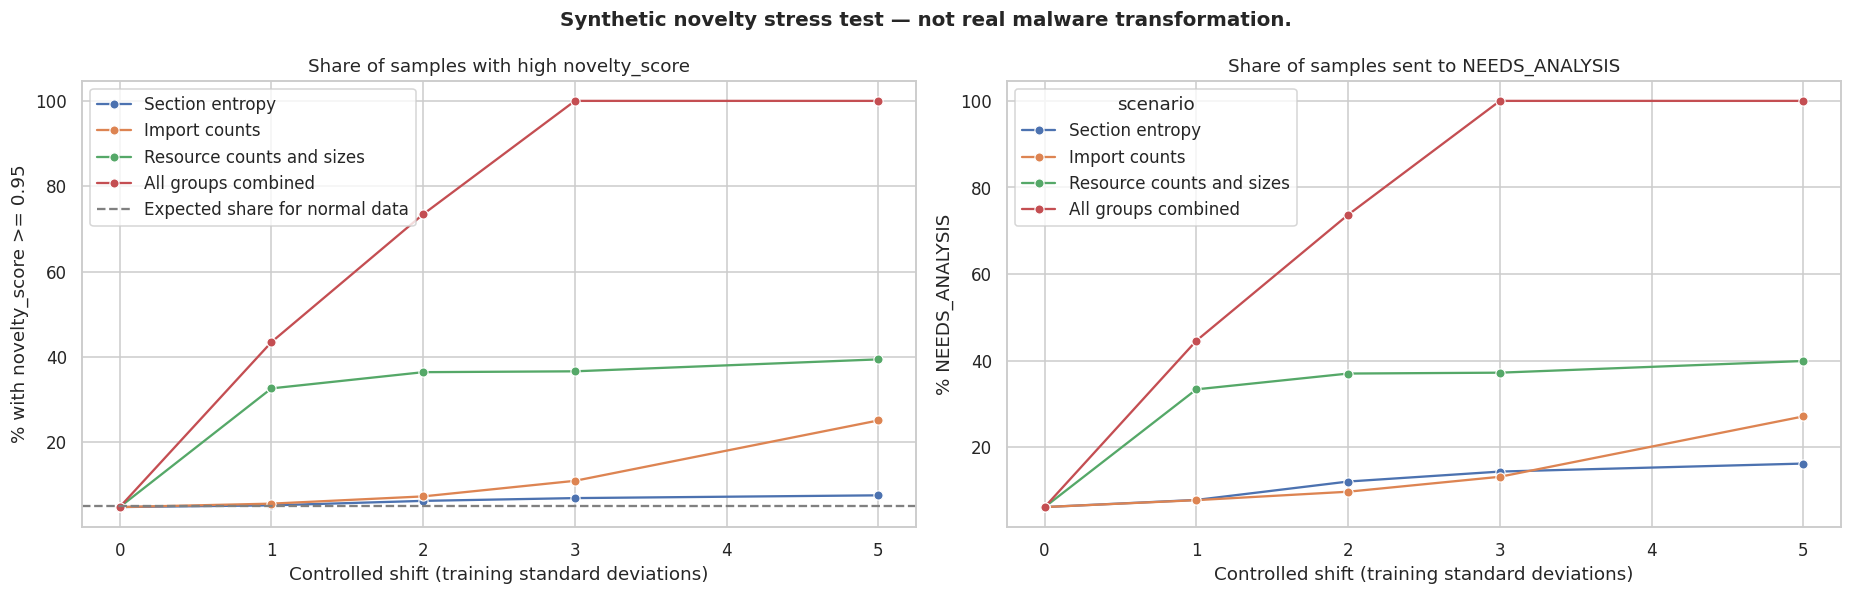

Section entropy: high-novelty share goes from 4.9% (shift of 0 std) to 7.6% (shift of 5 std).
Import counts: high-novelty share goes from 4.9% (shift of 0 std) to 25.1% (shift of 5 std).
Resource counts and sizes: high-novelty share goes from 4.9% (shift of 0 std) to 39.5% (shift of 5 std).
All groups combined: high-novelty share goes from 4.9% (shift of 0 std) to 100.0% (shift of 5 std).

Reminder: Synthetic novelty stress test — not real malware transformation. It shows the detector reacts to structural change; it is not evidence of real-world zero-day detection.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
sns.lineplot(data=stress_results, x="shift_in_std", y="high_novelty_percent", hue="scenario", marker="o", ax=axes[0])
axes[0].axhline(100 * (1 - TRIAGE_SETTINGS["novelty_threshold"]), linestyle="--", color="grey",
                label="Expected share for normal data")
axes[0].set_title("Share of samples with high novelty_score")
axes[0].set_xlabel("Controlled shift (training standard deviations)")
axes[0].set_ylabel(f"% with novelty_score >= {TRIAGE_SETTINGS['novelty_threshold']}")
axes[0].legend()
sns.lineplot(data=stress_results, x="shift_in_std", y="needs_analysis_percent", hue="scenario", marker="o", ax=axes[1])
axes[1].set_title("Share of samples sent to NEEDS_ANALYSIS")
axes[1].set_xlabel("Controlled shift (training standard deviations)")
axes[1].set_ylabel("% NEEDS_ANALYSIS")
fig.suptitle(STRESS_TEST_LABEL, fontsize=13, fontweight="bold")
save_and_show(fig, "09_synthetic_novelty_stress_test.png")

# We describe the result using the real numbers, whatever they turn out to be.
smallest_shift = min(STRESS_TEST_SHIFTS_IN_STD)
largest_shift = max(STRESS_TEST_SHIFTS_IN_STD)
for scenario_name in stress_groups:
    scenario = stress_results[stress_results["scenario"] == scenario_name].set_index("shift_in_std")
    print(f"{scenario_name}: high-novelty share goes from {scenario.loc[smallest_shift, 'high_novelty_percent']:.1f}% "
          f"(shift of {smallest_shift} std) to {scenario.loc[largest_shift, 'high_novelty_percent']:.1f}% "
          f"(shift of {largest_shift} std).")
print("\nReminder:", STRESS_TEST_LABEL, "It shows the detector reacts to structural change; "
      "it is not evidence of real-world zero-day detection.")

## Section 10 — SHAP explainability

> **SHAP is like a receipt. It shows which features pushed the model toward its decision.**

Every prediction starts from the model's average output. Each feature then adds or subtracts a little:

* a **positive** SHAP value pushes the sample **towards_malware**,
* a **negative** SHAP value pushes it **towards_benign**.

The SHAP values are in *log-odds* (the model's internal score before it becomes a probability). Bigger size = bigger push.

We use `shap.TreeExplainer`, which computes exact SHAP values for tree models. We also check that it matches XGBoost's own built-in SHAP calculation, because the API uses the built-in one (so the API does not need the heavy `shap` library).

SHAP explains the **classifier only**. The novelty score comes from the separate Isolation Forest.

In [ ]:
# We explain a random sample of test rows. The thresholds are frozen, so this is explanation, not tuning.
explainer = shap.TreeExplainer(xgb_model)
shap_rows = X_test_model.sample(n=min(SHAP_SAMPLE_SIZE, len(X_test_model)), random_state=RANDOM_STATE)
shap_explanation = explainer(shap_rows)
if shap_explanation.values.ndim != 2:
    raise RuntimeError(
        f"Expected one SHAP value per feature (2-D array), got shape {shap_explanation.values.shape}. "
        "Check the shap and xgboost versions."
    )

# Cross-check: XGBoost's built-in SHAP (pred_contribs) must give the same numbers as the shap library.
native_contributions = xgb_model.get_booster().predict(xgb.DMatrix(shap_rows), pred_contribs=True)[:, :-1]
largest_difference = float(np.max(np.abs(native_contributions - shap_explanation.values)))
print(f"Largest difference between shap.TreeExplainer and XGBoost's built-in SHAP: {largest_difference:.2e}")
if largest_difference > 1e-3:
    raise RuntimeError("shap.TreeExplainer and XGBoost pred_contribs disagree. The API explanations would not match.")
print("[OK] Both SHAP calculations agree, so the API's explanations match this notebook.")

Largest difference between shap.TreeExplainer and XGBoost's built-in SHAP: 0.00e+00
[OK] Both SHAP calculations agree, so the API's explanations match this notebook.


,mean_abs_shap
VersionInformationSize,2.1793
SectionsMaxEntropy,1.2450
ImageBase,1.1496
MajorLinkerVersion,0.7230
SizeOfStackReserve,0.5825
CheckSum,0.4702
Subsystem,0.3826
Characteristics,0.3695
SectionsMeanEntropy,0.3638
MajorOperatingSystemVersion,0.3530


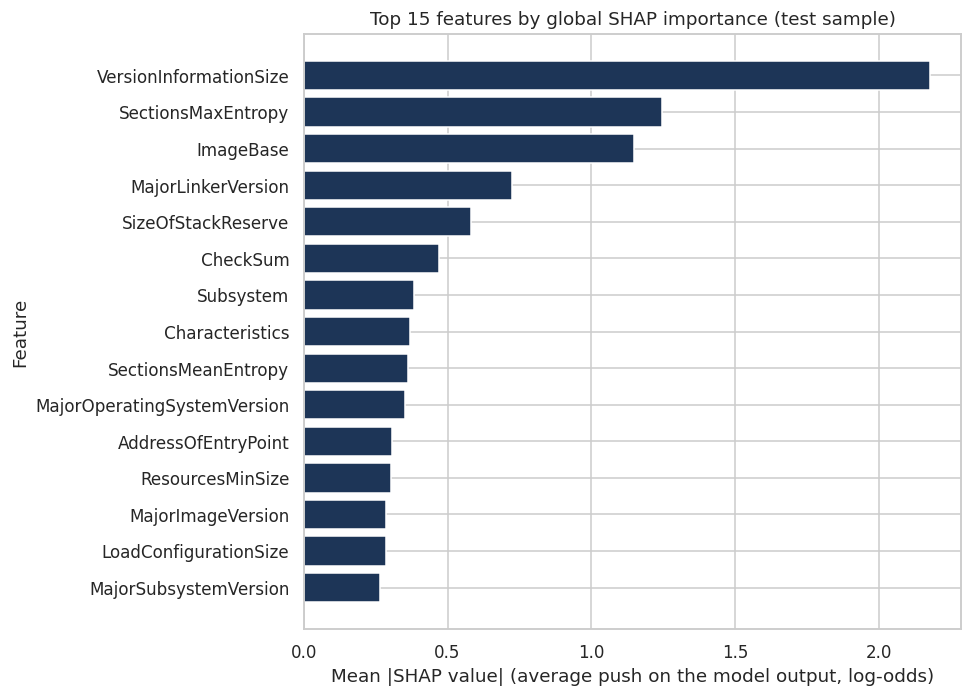

In [ ]:
# Global importance = the average size of each feature's push, over many samples.
mean_absolute_shap = pd.Series(
    np.abs(shap_explanation.values).mean(axis=0), index=MODEL_FEATURE_NAMES
).sort_values(ascending=False)
top_features = mean_absolute_shap.head(TOP_N_FEATURES)
display(top_features.rename("mean_abs_shap").round(4).to_frame())

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(top_features.index[::-1], top_features.values[::-1], color="#1d3557")
ax.set_title(f"Top {TOP_N_FEATURES} features by global SHAP importance (test sample)")
ax.set_xlabel("Mean |SHAP value| (average push on the model output, log-odds)")
ax.set_ylabel("Feature")
save_and_show(fig, "10_shap_global_importance.png")

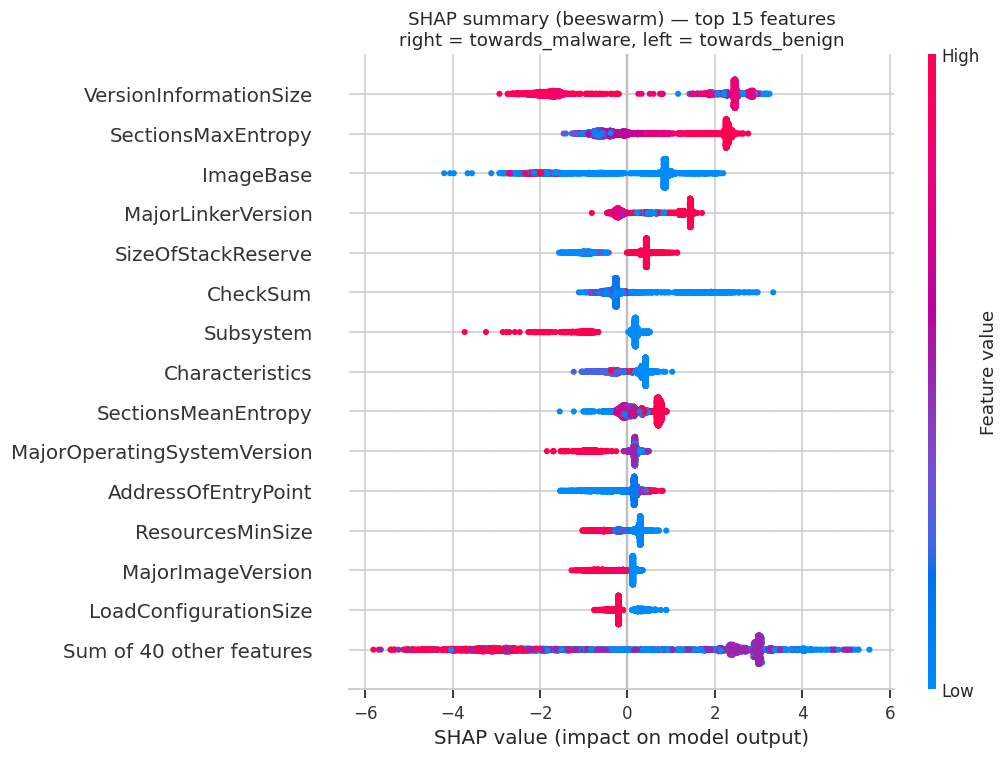

In [ ]:
# The beeswarm shows every sample as a dot: position = push direction and size, colour = feature value.
shap.plots.beeswarm(shap_explanation, max_display=TOP_N_FEATURES, show=False)
beeswarm_figure = plt.gcf()
plt.title(f"SHAP summary (beeswarm) — top {TOP_N_FEATURES} features\nright = towards_malware, left = towards_benign")
save_and_show(beeswarm_figure, "10_shap_beeswarm.png", tight=False)

MALWARE example (test row 67992):


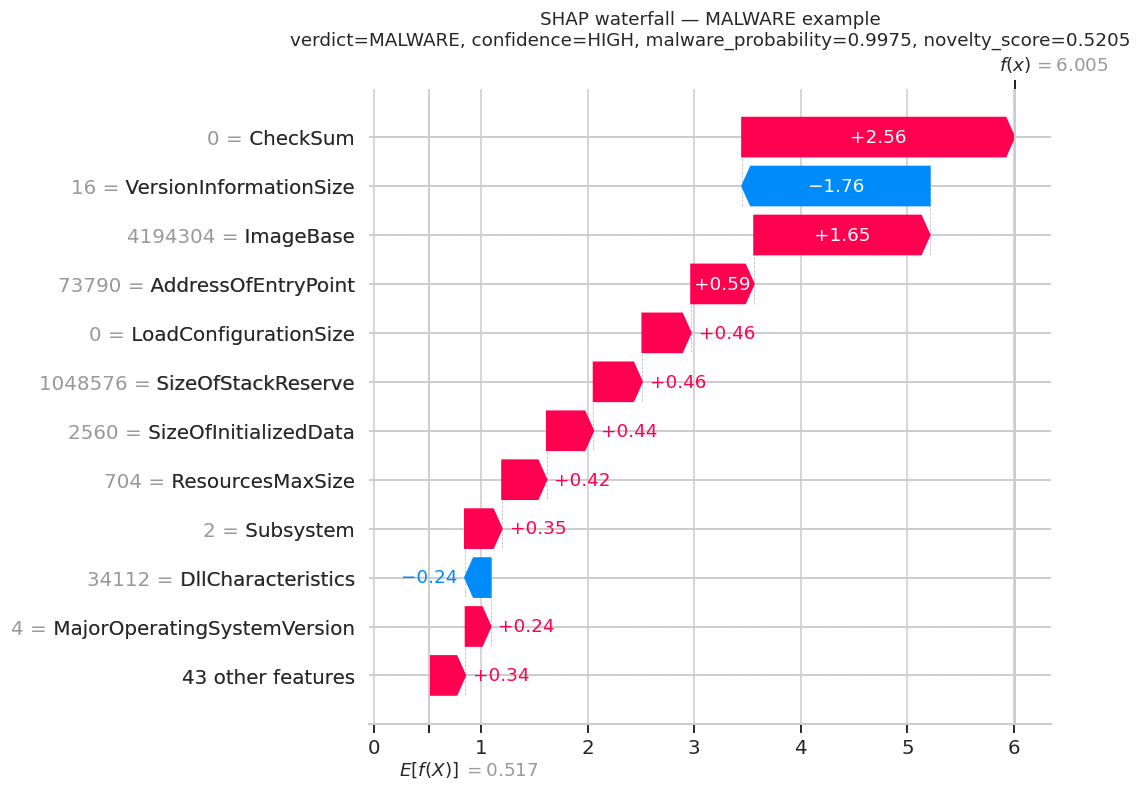

,feature,raw_value,shap_value,direction
0,CheckSum,0.0,2.55674,towards_malware
1,VersionInformationSize,16.0,-1.76280,towards_benign
2,ImageBase,4194304.0,1.64948,towards_malware
3,AddressOfEntryPoint,73790.0,0.59099,towards_malware
4,LoadConfigurationSize,0.0,0.45775,towards_malware
5,SizeOfStackReserve,1048576.0,0.45671,towards_malware
6,SizeOfInitializedData,2560.0,0.43886,towards_malware
7,ResourcesMaxSize,704.0,0.41965,towards_malware
8,Subsystem,2.0,0.34897,towards_malware
9,DllCharacteristics,34112.0,-0.24460,towards_benign


In [ ]:
def shap_contribution_table(feature_names, shap_values, raw_row, top_n):
    """The top features for one sample: raw value, SHAP value and direction (towards_malware/towards_benign)."""
    order = np.argsort(-np.abs(shap_values), kind="stable")[:top_n]
    return pd.DataFrame(
        [
            {
                "feature": feature_names[position],
                "raw_value": raw_row[feature_names[position]],
                "shap_value": round(float(shap_values[position]), 5),
                "direction": triage_rules.shap_direction(float(shap_values[position])),
            }
            for position in order
        ]
    )


def explain_test_sample(row_id, title, file_name):
    """Waterfall plot + contribution table for one test sample."""
    row_result = test_results.loc[row_id]
    single_explanation = explainer(X_test_model.loc[[row_id]])[0]
    shap.plots.waterfall(single_explanation, max_display=12, show=False)
    waterfall_figure = plt.gcf()
    plt.title(
        f"{title}\nverdict={row_result['verdict']}, confidence={row_result['confidence']}, "
        f"malware_probability={row_result['malware_probability']:.4f}, novelty_score={row_result['novelty_score']:.4f}"
    )
    save_and_show(waterfall_figure, file_name, tight=False)
    table = shap_contribution_table(
        MODEL_FEATURE_NAMES, single_explanation.values, X_test.loc[row_id], TOP_SHAP_FEATURES_PER_SAMPLE * 2
    )
    display(table)
    return table


def pick_example(candidate_ids, description):
    """Pick one random example (fixed seed). Say so clearly if there is none."""
    if len(candidate_ids) == 0:
        print(f"No test sample matched: {description}. This example is skipped (nothing is hidden: there were none).")
        return None
    return np.random.default_rng(RANDOM_STATE).choice(np.asarray(candidate_ids))


# Example 1: a MALWARE verdict that is correct (the sample really is malware).
malware_example_id = pick_example(
    test_results.index[(test_results["verdict"] == "MALWARE") & (test_results["y_malware"] == 1)],
    "correct MALWARE verdict",
)
if malware_example_id is not None:
    print(f"MALWARE example (test row {malware_example_id}):")
    malware_example_table = explain_test_sample(malware_example_id, "SHAP waterfall — MALWARE example",
                                                "10_shap_waterfall_malware.png")

NEEDS_ANALYSIS example (test row 85593), true class = malware. Reason: structurally novel compared with the training data.


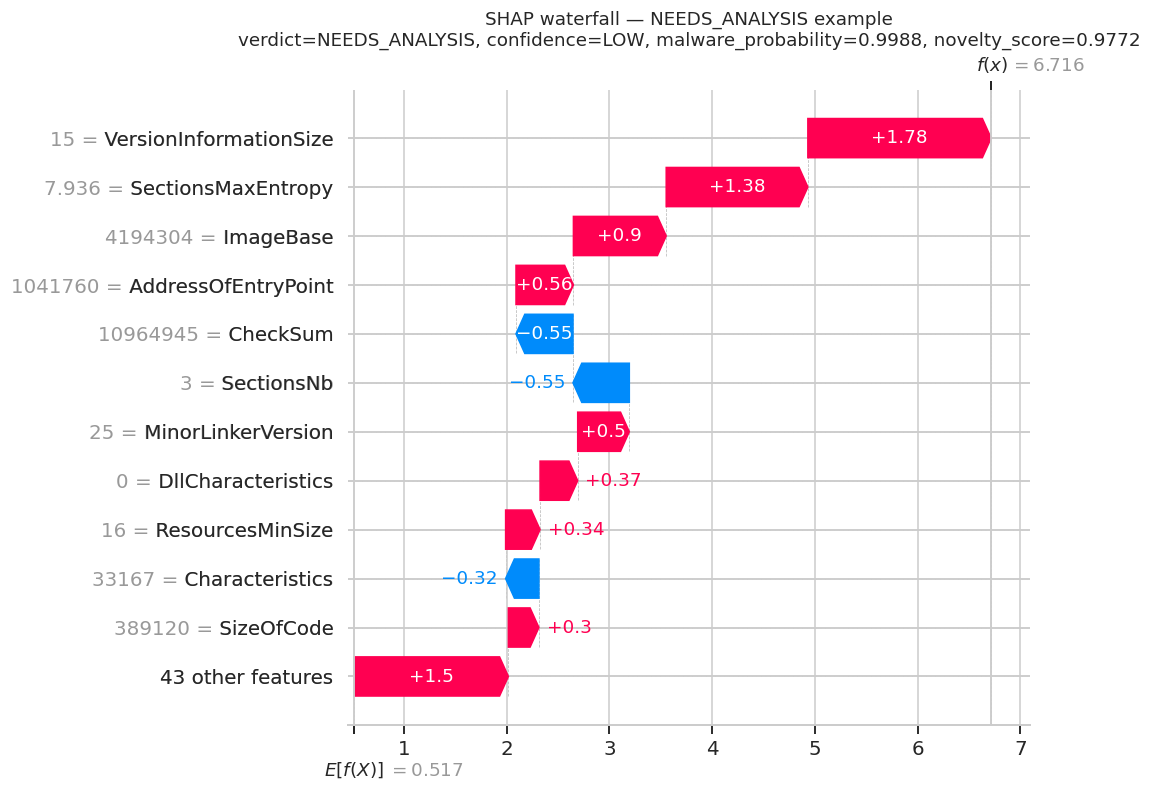

,feature,raw_value,shap_value,direction
0,VersionInformationSize,1.500000e+01,1.78458,towards_malware
1,SectionsMaxEntropy,7.935622e+00,1.37892,towards_malware
2,ImageBase,4.194304e+06,0.90341,towards_malware
3,AddressOfEntryPoint,1.041760e+06,0.55886,towards_malware
4,CheckSum,1.096494e+07,-0.55469,towards_benign
5,SectionsNb,3.000000e+00,-0.54837,towards_benign
6,MinorLinkerVersion,2.500000e+01,0.50239,towards_malware
7,DllCharacteristics,0.000000e+00,0.36635,towards_malware
8,ResourcesMinSize,1.600000e+01,0.33547,towards_malware
9,Characteristics,3.316700e+04,-0.32402,towards_benign


Remember: SHAP explains the classifier's probability. If the reason is 'structurally novel', that part comes from the novelty detector, not from these SHAP values.


In [ ]:
# Example 2: a NEEDS_ANALYSIS verdict, with the reason in plain words.
needs_analysis_example_id = pick_example(
    test_results.index[test_results["verdict"] == "NEEDS_ANALYSIS"], "NEEDS_ANALYSIS verdict"
)
if needs_analysis_example_id is not None:
    example_row = test_results.loc[needs_analysis_example_id]
    reason = triage_rules.needs_analysis_reason(
        example_row["malware_probability"], example_row["novelty_score"],
        TRIAGE_SETTINGS["malware_threshold"], TRIAGE_SETTINGS["benign_threshold"], TRIAGE_SETTINGS["novelty_threshold"],
    )
    print(f"NEEDS_ANALYSIS example (test row {needs_analysis_example_id}), true class = "
          f"{LABEL_NAMES[int(example_row['y_malware'])]}. Reason: {reason}.")
    needs_analysis_example_table = explain_test_sample(
        needs_analysis_example_id, "SHAP waterfall — NEEDS_ANALYSIS example", "10_shap_waterfall_needs_analysis.png"
    )
    print("Remember: SHAP explains the classifier's probability. If the reason is 'structurally novel', "
          "that part comes from the novelty detector, not from these SHAP values.")

## Section 11 — Export model artifacts

The API needs the **whole** pipeline, not just the classifier:

| File | What it is |
|---|---|
| `xgb_malware_model.joblib` | The trained XGBoost classifier |
| `iforest_novelty_model.joblib` | The trained Isolation Forest |
| `preprocessor.joblib` | Imputers + encoder, fitted on training data |
| `novelty_score_transformer.joblib` | Training-fitted percentile mapping (raw anomaly score → novelty_score) |
| `thresholds.json` | Frozen thresholds (saved in Section 6) |
| `feature_schema.json` | Which features the API must send, their types and training ranges |
| `shap_feature_names.json` | Feature order used by the model and SHAP |
| `model_metadata.json` | Names, versions, date, counts, thresholds and results |

Everything goes into `ml_package/artifacts/`.

In [ ]:
def build_feature_schema():
    """Describe exactly which inputs the API must send, and what training data looked like."""
    return {
        "schema_version": 1,
        "required_features": list(X.columns),
        "numeric_features": list(numeric_columns),
        "categorical_features": list(categorical_columns),
        "model_feature_order": MODEL_FEATURE_NAMES,
        "excluded_identifier_columns": cleaning_report["dropped_identifier_columns"]
        + cleaning_report["dropped_id_like_text_columns"],
        "target_column": TARGET_COLUMN,
        "label_meaning": "y_malware = 1 - legitimate, so 1 = malware and 0 = benign",
        "missing_value_policy": "A feature may be null (None). Numeric gaps are filled with the training median; "
        "text gaps with the most frequent training value.",
        "numeric_feature_training_summary": {
            column: {
                "min": X_train[column].min(),
                "median": X_train[column].median(),
                "max": X_train[column].max(),
            }
            for column in numeric_columns
        },
        "categorical_feature_training_values": {
            column: sorted(X_train[column].dropna().unique().tolist()) for column in categorical_columns
        },
    }


def build_model_metadata():
    """Everything someone needs to know about this model version, in one file."""
    return {
        "project": "UNKNOWN-FIRST — Novelty-Aware Malware Triage System",
        "team": "Garnet_Chronicles",
        "classifier_name": "XGBClassifier",
        "classifier_version": MODEL_VERSION,
        "classifier_params": XGB_PARAMS,
        "novelty_detector_name": "IsolationForest",
        "novelty_detector_params": IFOREST_PARAMS,
        "novelty_score_method": "novelty_score = training-fitted empirical percentile (QuantileTransformer, "
        "uniform output) of the Isolation Forest anomaly score (-score_samples), clipped to [0, 1].",
        "training_date_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "feature_count": len(MODEL_FEATURE_NAMES),
        "feature_names": MODEL_FEATURE_NAMES,
        "random_state": RANDOM_STATE,
        "thresholds": TRIAGE_SETTINGS,
        "dataset_file": DATA_PATH.name,
        "dataset_row_count": int(raw_df.shape[0]),
        "dataset_column_count": int(raw_df.shape[1]),
        "dataset_feature_count": int(X.shape[1]),
        "rows_used_after_cleaning": int(len(X)),
        "cleaning_report": cleaning_report,
        "split_sizes": {"train": len(X_train), "validation": len(X_val), "test": len(X_test)},
        "validation_classifier_metrics": val_classifier_metrics,
        "test_classifier_metrics": test_classifier_metrics,
        "test_triage_metrics": test_triage_metrics,
        "library_versions": LIBRARY_VERSIONS,
        "system_statement": SYSTEM_STATEMENT,
        "limitations": [
            "Static PE features only; no behaviour, memory or network information.",
            "Not a zero-day, AI-generated, polymorphic or fileless malware detector.",
            "novelty_score is relative to this training data only.",
            "Confidence (HIGH/MEDIUM/LOW) is a transparent rule, not a calibrated probability.",
        ],
    }


artifact_paths = {name: ARTIFACTS_DIR / file_name for name, file_name in ARTIFACT_FILE_NAMES.items()}
joblib.dump(xgb_model, artifact_paths["classifier"])
joblib.dump(iforest, artifact_paths["novelty_detector"])
joblib.dump(preprocessor, artifact_paths["preprocessor"])
joblib.dump(novelty_transformer, artifact_paths["novelty_transformer"])
save_json(build_feature_schema(), artifact_paths["feature_schema"])
save_json(MODEL_FEATURE_NAMES, artifact_paths["shap_feature_names"])
save_json(build_model_metadata(), artifact_paths["model_metadata"])

# thresholds.json was frozen in Section 6; we only confirm it is still there and unchanged.
if not artifact_paths["thresholds"].is_file():
    raise FileNotFoundError(f"{artifact_paths['thresholds']} is missing. Re-run Section 6.")
frozen_on_disk = load_json(artifact_paths["thresholds"])
if any(not math.isclose(frozen_on_disk[name], value) for name, value in TRIAGE_SETTINGS.items()):
    raise RuntimeError("thresholds.json on disk does not match the frozen TRIAGE_SETTINGS.")
print("[OK] thresholds.json is present and matches the frozen settings.")

Saved /content/drive/MyDrive/UNKNOWN_FIRST/ml_package/artifacts/feature_schema.json
Saved /content/drive/MyDrive/UNKNOWN_FIRST/ml_package/artifacts/shap_feature_names.json
Saved /content/drive/MyDrive/UNKNOWN_FIRST/ml_package/artifacts/model_metadata.json
[OK] thresholds.json is present and matches the frozen settings.


In [ ]:
# We load every saved model back and check it gives the same numbers as the in-memory model.
check_rows = X_val.head(500)
loaded_preprocessor = joblib.load(artifact_paths["preprocessor"])
loaded_classifier = joblib.load(artifact_paths["classifier"])
loaded_iforest = joblib.load(artifact_paths["novelty_detector"])
loaded_novelty_transformer = joblib.load(artifact_paths["novelty_transformer"])

loaded_model_input = loaded_preprocessor.transform(check_rows)
reload_checks = {
    "preprocessor": np.allclose(loaded_model_input.to_numpy(), preprocessor.transform(check_rows).to_numpy()),
    "classifier": np.allclose(
        predict_malware_probability(loaded_classifier, loaded_model_input),
        predict_malware_probability(xgb_model, loaded_model_input),
    ),
    "novelty detector + transformer": np.allclose(
        compute_novelty_score(loaded_iforest, loaded_novelty_transformer, loaded_model_input),
        compute_novelty_score(iforest, novelty_transformer, loaded_model_input),
    ),
}
for component, matches in reload_checks.items():
    if not matches:
        raise RuntimeError(f"The saved {component} does not reproduce the in-memory results.")
    print(f"[OK] saved {component} reproduces the in-memory results")

print("\nArtifacts folder:", ARTIFACTS_DIR)
for name, path in artifact_paths.items():
    print(f"  {path.name:<36} {path.stat().st_size / 1024:>10.1f} KB")

[OK] saved preprocessor reproduces the in-memory results
[OK] saved classifier reproduces the in-memory results
[OK] saved novelty detector + transformer reproduces the in-memory results

Artifacts folder: /content/drive/MyDrive/UNKNOWN_FIRST/ml_package/artifacts
  xgb_malware_model.joblib                  899.2 KB
  iforest_novelty_model.joblib             1506.9 KB
  preprocessor.joblib                         5.2 KB
  novelty_score_transformer.joblib           16.2 KB
  thresholds.json                             2.1 KB
  feature_schema.json                         9.7 KB
  shap_feature_names.json                     1.2 KB
  model_metadata.json                         4.8 KB


## Section 12 — Prediction function: `predict_triage(feature_dict) -> dict`

This is the function the API will call. It lives in `ml_package/predictor.py` and uses **only the saved artifacts**, never notebook variables. It:

1. checks that every required feature is present,
2. rejects unexpected or malformed inputs with a clear error,
3. applies the saved preprocessing,
4. calculates `malware_probability`,
5. calculates `novelty_score`,
6. applies the frozen thresholds,
7. assigns the confidence label,
8. returns the top 5 SHAP feature contributions.

The top SHAP values come from XGBoost's built-in TreeSHAP (`pred_contribs=True`). Section 10 showed that it gives the same numbers as `shap.TreeExplainer`, and it keeps the API free of the heavy `shap` dependency.

In [ ]:
%%writefile "{PREDICTOR_PATH}"
"""
UNKNOWN-FIRST inference: predict_triage(feature_dict) -> dict

This module only uses the saved files in the artifacts/ folder, so it works inside
any Python service (for example FastAPI) without the training notebook.

This system combines malware classification with novelty detection and abstention.
A sample that is ambiguous or structurally unfamiliar is sent to NEEDS_ANALYSIS
instead of forcing a binary decision. It does not detect zero-day, AI-generated,
polymorphic or fileless malware.
"""
import json
import math
import os
import threading
from collections.abc import Mapping
from numbers import Real
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import xgboost as xgb

from .triage_rules import shap_direction, triage_sample

# The artifacts live next to this file. Set UNKNOWN_FIRST_ARTIFACTS_DIR to use another folder.
DEFAULT_ARTIFACTS_DIR = Path(__file__).resolve().parent / "artifacts"
ARTIFACTS_DIR_ENV_VAR = "UNKNOWN_FIRST_ARTIFACTS_DIR"

REQUIRED_ARTIFACT_FILES = {
    "classifier": "xgb_malware_model.joblib",
    "novelty_detector": "iforest_novelty_model.joblib",
    "preprocessor": "preprocessor.joblib",
    "novelty_transformer": "novelty_score_transformer.joblib",
    "thresholds": "thresholds.json",
    "feature_schema": "feature_schema.json",
}
THRESHOLD_KEYS = (
    "malware_threshold",
    "benign_threshold",
    "novelty_threshold",
    "high_confidence_margin",
    "high_confidence_max_novelty",
)
TOP_SHAP_FEATURE_COUNT = 5

_cached_artifacts = None
_cache_lock = threading.Lock()


def get_artifacts_dir():
    """The folder the artifacts are loaded from."""
    return Path(os.environ.get(ARTIFACTS_DIR_ENV_VAR, DEFAULT_ARTIFACTS_DIR))


def _read_json(path):
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)


def load_artifacts(force_reload=False):
    """Load every saved artifact once and reuse it for all predictions.

    Call this once when the API starts, so the first request is not slow.
    """
    global _cached_artifacts
    with _cache_lock:
        if _cached_artifacts is not None and not force_reload:
            return _cached_artifacts

        folder = get_artifacts_dir()
        missing_files = [name for name in REQUIRED_ARTIFACT_FILES.values() if not (folder / name).is_file()]
        if missing_files:
            raise FileNotFoundError(f"Missing artifact files in {folder}: {missing_files}")

        schema = _read_json(folder / REQUIRED_ARTIFACT_FILES["feature_schema"])
        thresholds = _read_json(folder / REQUIRED_ARTIFACT_FILES["thresholds"])
        missing_keys = [key for key in THRESHOLD_KEYS if key not in thresholds]
        if missing_keys:
            raise KeyError(f"thresholds.json is missing these keys: {missing_keys}")

        classifier = joblib.load(folder / REQUIRED_ARTIFACT_FILES["classifier"])
        booster = classifier.get_booster()
        model_features = list(schema["model_feature_order"])
        if list(booster.feature_names or []) != model_features:
            raise ValueError("The classifier's feature names do not match feature_schema.json (model_feature_order).")

        _cached_artifacts = {
            "preprocessor": joblib.load(folder / REQUIRED_ARTIFACT_FILES["preprocessor"]),
            "classifier": classifier,
            "booster": booster,
            "novelty_detector": joblib.load(folder / REQUIRED_ARTIFACT_FILES["novelty_detector"]),
            "novelty_transformer": joblib.load(folder / REQUIRED_ARTIFACT_FILES["novelty_transformer"]),
            "thresholds": {key: float(thresholds[key]) for key in THRESHOLD_KEYS},
            "schema": schema,
            "model_features": model_features,
        }
        return _cached_artifacts


def _clean_numeric_value(name, value, problems):
    """Numbers are accepted as int/float. None (or NaN) means 'unknown' and is filled by the imputer."""
    if value is None:
        return np.nan
    if isinstance(value, (bool, np.bool_)) or not isinstance(value, Real):
        problems.append(f"'{name}' must be a number, got {type(value).__name__} ({value!r}).")
        return np.nan
    number = float(value)
    if math.isinf(number):
        problems.append(f"'{name}' must be a finite number, got {value!r}.")
    return number


def _clean_categorical_value(name, value, problems):
    """Categorical features are accepted as text (str). None means 'unknown'."""
    if value is None:
        return np.nan
    if isinstance(value, str):
        return value
    problems.append(f"'{name}' must be text (str) or None, got {type(value).__name__} ({value!r}).")
    return np.nan


def _build_input_frame(feature_dict, schema):
    """Validate the input and turn it into a one-row DataFrame in the training column order."""
    if not isinstance(feature_dict, Mapping):
        raise TypeError(f"feature_dict must be a dict, got {type(feature_dict).__name__}.")

    required = list(schema["required_features"])
    required_set = set(required)
    numeric = set(schema["numeric_features"])
    problems = []

    non_text_keys = [key for key in feature_dict if not isinstance(key, str)]
    if non_text_keys:
        problems.append(f"feature names must be strings, got: {non_text_keys!r}")
    missing = [name for name in required if name not in feature_dict]
    if missing:
        problems.append(f"missing required features ({len(missing)}): {missing}")
    unexpected = sorted(key for key in feature_dict if isinstance(key, str) and key not in required_set)
    if unexpected:
        problems.append(
            f"unexpected features ({len(unexpected)}): {unexpected}. "
            "Only send the features in feature_schema.json (identifiers such as Name or md5 are not model inputs)."
        )

    row = {}
    for name in required:
        if name not in feature_dict:
            continue
        if name in numeric:
            row[name] = _clean_numeric_value(name, feature_dict[name], problems)
        else:
            row[name] = _clean_categorical_value(name, feature_dict[name], problems)

    if problems:
        raise ValueError("Invalid feature_dict:\n  - " + "\n  - ".join(problems))

    frame = pd.DataFrame([row], columns=required)
    for name in required:
        frame[name] = frame[name].astype("float64" if name in numeric else "object")
    return frame


def _to_model_frame(artifacts, input_frame):
    """Apply the saved preprocessing and return a DataFrame in the model's feature order."""
    transformed = artifacts["preprocessor"].transform(input_frame)
    model_features = artifacts["model_features"]
    if hasattr(transformed, "columns") and list(transformed.columns) != model_features:
        raise RuntimeError("The preprocessor output columns do not match the model feature order.")
    values = np.asarray(transformed, dtype=np.float64)
    if values.shape != (len(input_frame), len(model_features)):
        raise RuntimeError(f"Unexpected preprocessed shape {values.shape}.")
    return pd.DataFrame(values, columns=model_features, index=input_frame.index)


def _json_raw_value(value):
    """Return the caller's original value in a JSON-friendly form (float, str or None)."""
    if value is None or isinstance(value, str):
        return value
    number = float(value)
    return None if math.isnan(number) else number


def _top_shap_features(artifacts, model_input, feature_dict):
    """Top SHAP contributions from XGBoost's built-in TreeSHAP (same values as shap.TreeExplainer)."""
    contributions = artifacts["booster"].predict(xgb.DMatrix(model_input), pred_contribs=True)[0, :-1]
    order = np.argsort(-np.abs(contributions), kind="stable")[:TOP_SHAP_FEATURE_COUNT]
    top_features = []
    for position in order:
        name = artifacts["model_features"][position]
        shap_value = float(contributions[position])
        top_features.append(
            {
                "feature": name,
                "raw_value": _json_raw_value(feature_dict[name]),
                "shap_value": shap_value,
                "direction": shap_direction(shap_value),
            }
        )
    return top_features


def predict_triage(feature_dict: dict) -> dict:
    """Triage one PE sample from its static features.

    Returns:
        {
            "verdict": "MALWARE" | "BENIGN" | "NEEDS_ANALYSIS",
            "malware_probability": float,
            "novelty_score": float,        # 0 = very familiar, 1 = highly novel
            "confidence": "HIGH" | "MEDIUM" | "LOW",   # a transparent rule, not a calibrated probability
            "top_shap_features": [{"feature", "raw_value", "shap_value", "direction"}, ...],
        }

    Raises:
        TypeError / ValueError with a clear message for missing, unexpected or malformed inputs.
    """
    artifacts = load_artifacts()
    input_frame = _build_input_frame(feature_dict, artifacts["schema"])
    model_input = _to_model_frame(artifacts, input_frame)

    malware_probability = float(artifacts["classifier"].predict_proba(model_input)[0, 1])
    raw_novelty = -artifacts["novelty_detector"].score_samples(model_input)
    novelty_percentile = artifacts["novelty_transformer"].transform(raw_novelty.reshape(-1, 1)).ravel()[0]
    novelty_score = float(np.clip(novelty_percentile, 0.0, 1.0))

    verdict, confidence = triage_sample(malware_probability, novelty_score, **artifacts["thresholds"])

    return {
        "verdict": verdict,
        "malware_probability": malware_probability,
        "novelty_score": novelty_score,
        "confidence": confidence,
        "top_shap_features": _top_shap_features(artifacts, model_input, feature_dict),
    }

Writing /content/drive/MyDrive/UNKNOWN_FIRST/ml_package/predictor.py


In [ ]:
# We import the predictor we just wrote and force it to load the freshly saved artifacts.
importlib.invalidate_caches()
import ml_package.predictor as predictor_module  # noqa: E402

predictor_module = importlib.reload(predictor_module)
predictor_module.load_artifacts(force_reload=True)
predict_triage = predictor_module.predict_triage


def row_to_feature_dict(row):
    """Turn one raw feature row into the plain dict an API client would send (missing values become None)."""
    feature_dict = {}
    for name, value in row.items():
        if pd.isna(value):
            feature_dict[name] = None
        elif name in numeric_columns:
            number = float(value)
            feature_dict[name] = int(number) if number.is_integer() else number
        else:
            feature_dict[name] = str(value)
    return feature_dict


# One real example request, taken from the test set, shown the way the API would return it.
example_row_id = malware_example_id if malware_example_id is not None else X_test.index[0]
example_request = row_to_feature_dict(X_test.loc[example_row_id])
example_response = predict_triage(example_request)
print(f"predict_triage() output for test row {example_row_id}:")
print(json.dumps(example_response, indent=2))

if needs_analysis_example_id is not None:
    print(f"\npredict_triage() output for the NEEDS_ANALYSIS example (test row {needs_analysis_example_id}):")
    print(json.dumps(predict_triage(row_to_feature_dict(X_test.loc[needs_analysis_example_id])), indent=2))

predict_triage() output for test row 67992:
{
  "verdict": "MALWARE",
  "malware_probability": 0.9975390434265137,
  "novelty_score": 0.5205026910795264,
  "confidence": "HIGH",
  "top_shap_features": [
    {
      "feature": "CheckSum",
      "raw_value": 0.0,
      "shap_value": 2.55674409866333,
      "direction": "towards_malware"
    },
    {
      "feature": "VersionInformationSize",
      "raw_value": 16.0,
      "shap_value": -1.7628018856048584,
      "direction": "towards_benign"
    },
    {
      "feature": "ImageBase",
      "raw_value": 4194304.0,
      "shap_value": 1.6494842767715454,
      "direction": "towards_malware"
    },
    {
      "feature": "AddressOfEntryPoint",
      "raw_value": 73790.0,
      "shap_value": 0.5909910798072815,
      "direction": "towards_malware"
    },
    {
      "feature": "LoadConfigurationSize",
      "raw_value": 0.0,
      "shap_value": 0.4577547311782837,
      "direction": "towards_malware"
    }
  ]
}

predict_triage() output for 

In [ ]:
# The saved-artifact predictor must reproduce the notebook's test results exactly.
consistency_rows = X_test.sample(n=min(200, len(X_test)), random_state=RANDOM_STATE)
mismatched_rows = []
call_times = []
for row_id, row in consistency_rows.iterrows():
    call_start = time.perf_counter()
    package_output = predict_triage(row_to_feature_dict(row))
    call_times.append(time.perf_counter() - call_start)
    expected = test_results.loc[row_id]
    same_result = (
        package_output["verdict"] == expected["verdict"]
        and package_output["confidence"] == expected["confidence"]
        and abs(package_output["malware_probability"] - expected["malware_probability"]) < 1e-6
        and abs(package_output["novelty_score"] - expected["novelty_score"]) < 1e-6
    )
    if not same_result:
        mismatched_rows.append(row_id)
if mismatched_rows:
    raise AssertionError(f"predict_triage differs from the notebook pipeline on test rows: {mismatched_rows[:10]}")
print(f"[OK] predict_triage matches the notebook results on {len(consistency_rows)} test rows.")
print(f"Average time per prediction: {1000 * np.mean(call_times):.1f} ms")

[OK] predict_triage matches the notebook results on 200 test rows.
Average time per prediction: 55.6 ms


In [ ]:
# Bad inputs must be rejected with a clear message. Each case below MUST raise an error.
first_feature = list(X.columns)[0]
bad_inputs = {
    "not a dict": [1, 2, 3],
    "missing a required feature": {name: value for name, value in example_request.items() if name != first_feature},
    "unexpected identifier field (md5)": {**example_request, "md5": "0123456789abcdef"},
}
if numeric_columns:
    first_numeric = numeric_columns[0]
    bad_inputs["text instead of a number"] = {**example_request, first_numeric: "not-a-number"}
    bad_inputs["infinite value"] = {**example_request, first_numeric: float("inf")}
    bad_inputs["boolean instead of a number"] = {**example_request, first_numeric: True}

for description, bad_input in bad_inputs.items():
    try:
        predict_triage(bad_input)
    except (TypeError, ValueError) as error:
        print(f"[OK] rejected ({description}):\n     {error}")
    else:
        raise AssertionError(f"predict_triage accepted a bad input ({description}). This must never happen.")

# A missing (None) value is allowed: the saved imputer fills it with the training median.
if numeric_columns:
    with_missing_value = {**example_request, numeric_columns[0]: None}
    print(f"\n[OK] None for '{numeric_columns[0]}' is accepted and imputed ->",
          predict_triage(with_missing_value)["verdict"])

[OK] rejected (not a dict):
     feature_dict must be a dict, got list.
[OK] rejected (missing a required feature):
     Invalid feature_dict:
  - missing required features (1): ['Machine']
[OK] rejected (unexpected identifier field (md5)):
     Invalid feature_dict:
  - unexpected features (1): ['md5']. Only send the features in feature_schema.json (identifiers such as Name or md5 are not model inputs).
[OK] rejected (text instead of a number):
     Invalid feature_dict:
  - 'Machine' must be a number, got str ('not-a-number').
[OK] rejected (infinite value):
     Invalid feature_dict:
  - 'Machine' must be a finite number, got inf.
[OK] rejected (boolean instead of a number):
     Invalid feature_dict:
  - 'Machine' must be a number, got bool (True).

[OK] None for 'Machine' is accepted and imputed -> MALWARE


## Section 13 — Save a real inference package

We finish `ml_package/` so Kaustubh can copy it straight into the FastAPI service:

```
ml_package/
├── __init__.py            exposes predict_triage and load_artifacts
├── predictor.py           predict_triage(feature_dict) -> dict
├── triage_rules.py        the shared verdict + confidence rules
├── requirements.txt       exact library versions used for training
├── README.md              how to use it from FastAPI
├── example_request.json   one real request body
└── artifacts/
    ├── xgb_malware_model.joblib
    ├── iforest_novelty_model.joblib
    ├── preprocessor.joblib
    ├── novelty_score_transformer.joblib
    ├── thresholds.json
    ├── feature_schema.json
    ├── shap_feature_names.json
    └── model_metadata.json
```

Then we prove it works in a **fresh Python process** that knows nothing about this notebook.

In [ ]:
%%writefile "{PACKAGE_INIT_PATH}"
"""UNKNOWN-FIRST: novelty-aware static PE malware triage (MALWARE / BENIGN / NEEDS_ANALYSIS)."""
from .predictor import load_artifacts, predict_triage

__all__ = ["predict_triage", "load_artifacts"]
__version__ = "1.0.0"

Writing /content/drive/MyDrive/UNKNOWN_FIRST/ml_package/__init__.py


In [ ]:
%%writefile "{PACKAGE_README_PATH}"
# UNKNOWN-FIRST ML package

Novelty-aware static Windows PE malware triage. Every call returns exactly one verdict:
`MALWARE`, `BENIGN` or `NEEDS_ANALYSIS`.

This system combines malware classification with novelty detection and abstention.
A sample that is ambiguous or structurally unfamiliar is sent to NEEDS_ANALYSIS instead
of forcing a binary decision. It is not a zero-day, AI-generated, polymorphic or
fileless malware detector.

## Install

```
pip install -r ml_package/requirements.txt
```

Use these exact versions. The saved models were created with them.

## Use

```python
from ml_package import load_artifacts, predict_triage

load_artifacts()                  # optional: call once at start-up so the first request is fast
result = predict_triage(feature_dict)
```

`feature_dict` must contain every name in `artifacts/feature_schema.json` → `required_features`
and nothing else (do not send `Name` or `md5`). Numeric features must be int/float.
`None` is allowed for an unknown value; it is filled with the training median.
Invalid input raises `TypeError` or `ValueError` with a clear message.
See `example_request.json` for a real request body.

## FastAPI sketch

```python
from fastapi import FastAPI, HTTPException
from ml_package import load_artifacts, predict_triage

app = FastAPI()
load_artifacts()

@app.post("/triage")
def triage(features: dict):
    try:
        return predict_triage(features)
    except (TypeError, ValueError) as error:
        raise HTTPException(status_code=422, detail=str(error))
```

## Output

```json
{
  "verdict": "MALWARE | BENIGN | NEEDS_ANALYSIS",
  "malware_probability": 0.0,
  "novelty_score": 0.0,
  "confidence": "HIGH | MEDIUM | LOW",
  "top_shap_features": [
    {"feature": "...", "raw_value": 0.0, "shap_value": 0.0, "direction": "towards_malware | towards_benign"}
  ]
}
```

* `novelty_score`: 0 = very familiar, 1 = more unusual than all training samples.
* `confidence` is a transparent rule, not a calibrated probability.
* SHAP values explain the classifier's malware probability (log-odds scale).

Writing /content/drive/MyDrive/UNKNOWN_FIRST/ml_package/README.md


In [ ]:
# requirements.txt pins the exact versions used here, because saved models depend on them.
# The API does not need shap: it uses XGBoost's built-in SHAP values.
package_requirements = [
    f"numpy=={np.__version__}",
    f"pandas=={pd.__version__}",
    f"scikit-learn=={sklearn.__version__}",
    f"xgboost=={xgb.__version__}",
    f"joblib=={joblib.__version__}",
]
PACKAGE_REQUIREMENTS_PATH.write_text("\n".join(package_requirements) + "\n", encoding="utf-8")
print(f"Saved {PACKAGE_REQUIREMENTS_PATH}:\n" + "\n".join(package_requirements))

# A real request body for the API team to test with.
save_json(example_request, EXAMPLE_REQUEST_PATH)

Saved /content/drive/MyDrive/UNKNOWN_FIRST/ml_package/requirements.txt:
numpy==2.1.3
pandas==2.2.3
scikit-learn==1.6.1
xgboost==3.4.1
joblib==1.6.0
Saved /content/drive/MyDrive/UNKNOWN_FIRST/ml_package/example_request.json


In [ ]:
# The real test: a brand-new Python process imports the package and makes a prediction.
# If this works, the package does not depend on anything that only exists in this notebook.
fresh_process_code = textwrap.dedent(
    f"""
    import json, sys
    sys.path.insert(0, {str(PROJECT_DIR)!r})
    from ml_package import predict_triage
    with open({str(EXAMPLE_REQUEST_PATH)!r}, encoding="utf-8") as handle:
        request = json.load(handle)
    print(json.dumps(predict_triage(request)))
    """
)
completed = subprocess.run(
    [sys.executable, "-c", fresh_process_code], capture_output=True, text=True, cwd=str(REPORTS_DIR)
)
if completed.returncode != 0:
    raise RuntimeError(f"The fresh-process package test failed:\n{completed.stderr}")
if completed.stderr.strip():
    print("Messages printed by the fresh process (warnings, not errors):\n" + completed.stderr)

fresh_output = json.loads(completed.stdout.strip().splitlines()[-1])
if fresh_output["verdict"] != example_response["verdict"] or not math.isclose(
    fresh_output["malware_probability"], example_response["malware_probability"], abs_tol=1e-9
):
    raise AssertionError("The fresh process gave a different answer from the notebook.")
print("[OK] A fresh Python process imported ml_package and returned:")
print(json.dumps(fresh_output, indent=2))

[OK] A fresh Python process imported ml_package and returned:
{
  "verdict": "MALWARE",
  "malware_probability": 0.9975390434265137,
  "novelty_score": 0.5205026910795264,
  "confidence": "HIGH",
  "top_shap_features": [
    {
      "feature": "CheckSum",
      "raw_value": 0.0,
      "shap_value": 2.55674409866333,
      "direction": "towards_malware"
    },
    {
      "feature": "VersionInformationSize",
      "raw_value": 16.0,
      "shap_value": -1.7628018856048584,
      "direction": "towards_benign"
    },
    {
      "feature": "ImageBase",
      "raw_value": 4194304.0,
      "shap_value": 1.6494842767715454,
      "direction": "towards_malware"
    },
    {
      "feature": "AddressOfEntryPoint",
      "raw_value": 73790.0,
      "shap_value": 0.5909910798072815,
      "direction": "towards_malware"
    },
    {
      "feature": "LoadConfigurationSize",
      "raw_value": 0.0,
      "shap_value": 0.4577547311782837,
      "direction": "towards_malware"
    }
  ]
}


In [ ]:
# Python cache folders are not needed in the package, so we remove them before zipping.
for cache_folder in list(PACKAGE_DIR.rglob("__pycache__")):
    shutil.rmtree(cache_folder)

print("ml_package contents:")
for path in sorted(PACKAGE_DIR.rglob("*")):
    if path.is_file():
        print(f"  {str(path.relative_to(PROJECT_DIR)):<50} {path.stat().st_size / 1024:>10.1f} KB")

# One zip file is the easiest way to hand the package to the API team.
package_zip_path = shutil.make_archive(str(PROJECT_DIR / "ml_package"), "zip", root_dir=PROJECT_DIR, base_dir="ml_package")
print(f"\nZipped package: {package_zip_path}")

ml_package contents:
  ml_package/README.md                                      2.0 KB
  ml_package/__init__.py                                    0.2 KB
  ml_package/artifacts/feature_schema.json                  9.7 KB
  ml_package/artifacts/iforest_novelty_model.joblib      1506.9 KB
  ml_package/artifacts/model_metadata.json                  4.8 KB
  ml_package/artifacts/novelty_score_transformer.joblib       16.2 KB
  ml_package/artifacts/preprocessor.joblib                  5.2 KB
  ml_package/artifacts/shap_feature_names.json              1.2 KB
  ml_package/artifacts/thresholds.json                      2.1 KB
  ml_package/artifacts/xgb_malware_model.joblib           899.2 KB
  ml_package/example_request.json                           1.5 KB
  ml_package/predictor.py                                   9.4 KB
  ml_package/requirements.txt                               0.1 KB
  ml_package/triage_rules.py                                5.7 KB

Zipped package: /content/drive/MyDriv

## Section 14 — Final summary

In [ ]:
def fmt_count(value):
    return f"{int(value):,}"


# The main table. Precision, recall and F1 describe the MALWARE verdict of the full system.
# ROC-AUC and PR-AUC describe how well the classifier ranks samples (they need probabilities).
malware_precision = test_triage_metrics["malware_verdict_precision"]
malware_recall = test_triage_metrics["malware_verdict_recall"]
malware_f1 = (
    2 * malware_precision * malware_recall / (malware_precision + malware_recall)
    if (malware_precision + malware_recall) > 0 else float("nan")
)
final_summary = pd.DataFrame(
    [
        ("Test samples", fmt_count(test_triage_metrics["total"])),
        ("MALWARE verdicts", fmt_count(test_triage_metrics["malware_verdicts"])),
        ("BENIGN verdicts", fmt_count(test_triage_metrics["benign_verdicts"])),
        ("NEEDS_ANALYSIS verdicts", fmt_count(test_triage_metrics["needs_analysis_verdicts"])),
        ("Coverage", as_percent(test_triage_metrics["coverage"])),
        ("Abstention rate", as_percent(test_triage_metrics["abstention_rate"])),
        ("Selective error rate", as_percent(test_triage_metrics["selective_error_rate"], 3)),
        ("Malware precision (MALWARE verdicts)", f"{malware_precision:.4f}"),
        ("Malware recall (MALWARE verdicts)", f"{malware_recall:.4f}"),
        ("F1 (MALWARE verdicts)", f"{malware_f1:.4f}"),
        ("ROC-AUC (classifier)", f"{test_classifier_metrics['roc_auc']:.4f}"),
        ("PR-AUC (classifier)", f"{test_classifier_metrics['pr_auc']:.4f}"),
    ],
    columns=["Metric", "Value"],
)
print("FINAL RESULTS — TEST SET (thresholds chosen on validation only)\n")
print(final_summary.to_string(index=False))

classifier_only = pd.DataFrame(
    [(name, f"{test_classifier_metrics[name]:.4f}") for name in ["accuracy", "precision", "recall", "f1"]],
    columns=["Classifier alone, forced binary at 0.5", "Value"],
)
print("\nFor comparison — the classifier alone, forced to decide every sample:\n")
print(classifier_only.to_string(index=False))

print("\nFinal threshold values (frozen, from validation):")
for name, value in TRIAGE_SETTINGS.items():
    print(f"  {name:<28} {value}")

final_summary.to_csv(REPORTS_DIR / "final_summary_test.csv", index=False)

FINAL RESULTS — TEST SET (thresholds chosen on validation only)

                              Metric  Value
                        Test samples 20,918
                    MALWARE verdicts 12,214
                     BENIGN verdicts  7,301
             NEEDS_ANALYSIS verdicts  1,403
                            Coverage 93.29%
                     Abstention rate  6.71%
                Selective error rate 0.297%
Malware precision (MALWARE verdicts) 0.9980
   Malware recall (MALWARE verdicts) 0.9633
               F1 (MALWARE verdicts) 0.9804
                ROC-AUC (classifier) 0.9995
                 PR-AUC (classifier) 0.9997

For comparison — the classifier alone, forced to decide every sample:

Classifier alone, forced binary at 0.5  Value
                              accuracy 0.9922
                             precision 0.9952
                                recall 0.9918
                                    f1 0.9935

Final threshold values (frozen, from validation):
  malware_

In [ ]:
# A short, data-driven recap. Every number here comes from the results above.
top_five_features = mean_absolute_shap.head(5).index.tolist()
print("What the classifier leaned on most (global SHAP):", ", ".join(top_five_features))
print(f"Novel vs familiar classifier error on test: {as_percent(test_novel_error, 3)} vs "
      f"{as_percent(test_familiar_error, 3)} (novelty_score >= {TRIAGE_SETTINGS['novelty_threshold']} = novel).")
print(f"Share of test samples sent to NEEDS_ANALYSIS: {as_percent(test_triage_metrics['abstention_rate'])}.")
print(f"Malware wrongly auto-cleared as BENIGN on test: {test_triage_metrics['missed_malware_called_benign']:,} "
      f"of {int(y_test.sum()):,} malware samples.")
print("\n" + SYSTEM_STATEMENT)

What the classifier leaned on most (global SHAP): VersionInformationSize, SectionsMaxEntropy, ImageBase, MajorLinkerVersion, SizeOfStackReserve
Novel vs familiar classifier error on test: 0.658% vs 0.791% (novelty_score >= 0.95 = novel).
Share of test samples sent to NEEDS_ANALYSIS: 6.71%.
Malware wrongly auto-cleared as BENIGN on test: 34 of 12,654 malware samples.

This system combines malware classification with novelty detection and abstention. A sample that is ambiguous or structurally unfamiliar is sent to NEEDS_ANALYSIS instead of forcing a binary decision.


### What we built,

**What the classifier learned.** XGBoost learned which *static* PE header, section, import and resource patterns tend to appear in malware versus benign files in this dataset. The SHAP section shows which features it relies on most. It learned patterns in these extracted numbers. It did not learn what a program actually does when it runs.

**What the novelty detector learned.** Isolation Forest learned what "normal-looking" PE structure is in our **training** data, without using labels. `novelty_score` says how unusual a new sample is compared with that training data: 0 = very familiar, 1 = more unusual than every training sample.

**Why the third verdict exists.** A classifier always gives *some* probability, even for a sample unlike anything it has seen. Forcing that sample into MALWARE or BENIGN hides the uncertainty. `NEEDS_ANALYSIS` is the honest answer when the probability is ambiguous **or** the sample is structurally unfamiliar. The automatic MALWARE/BENIGN decisions stay high quality, and a human looks at the rest.

**What the system can claim**

* This system combines malware classification with novelty detection and abstention. A sample that is ambiguous or structurally unfamiliar is sent to NEEDS_ANALYSIS instead of forcing a binary decision.
* The numbers above were measured on a held-out test set that was never used for training or threshold tuning.
* The novelty detector responds to controlled structural changes (Section 9, synthetic test).
* Every automatic decision comes with a SHAP "receipt" of the features that pushed it.

**What the system cannot claim**

* It cannot claim to detect zero-day malware, AI-generated malware, polymorphic malware or fileless malware.
* A high novelty score means "unlike our training data". It does not mean "new malware family".
* The Section 9 stress test uses synthetic feature changes, not real malware transformations.
* HIGH/MEDIUM/LOW confidence is a transparent rule, not a calibrated probability.
* Results only hold for PE files whose features are extracted in the same way as in `malware.csv`.